<a href="https://colab.research.google.com/github/arvindprabhu02/Agentic-Travel-Planning-System/blob/main/phase_2/Phase2_NB1_v22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All imports OK.
Mounted at /content/drive
DATA_DIR       : /content/drive/MyDrive/travel_planner/data
PHASE_1_OUTPUT : /content/drive/MyDrive/travel_planner/phase_1_output
OUTPUT_DIR     : /content/drive/MyDrive/travel_planner/phase_2a_output
Loading datasets...
  Attractions loaded   : 3110
  City aliases         : 24
  Category mappings    : 12
  Emotion entries      : 22
  Intent entries       : 12
  Request entries      : 13
  Handicraft entries   : 537
Loading Phi-3-mini model...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

  Model ready.

Query 3: I want to explore Tripura, Assam tea garden and manas wildlife sanctuary. Then travel to Bagdogra th...
Duration: 35d | Intent: Culture | Emotions: ['Curious', 'Adventurous', 'Joyful'] | Radius: 150 km
  [POI] 'Manas National Park' -> host city: Barpeta (will enforce specific-place visit)
Main POIs (13): ['Udaipur', 'Guwahati', 'Barpeta', 'Darjeeling', 'Gangtok', 'Kolkata', 'Sundarbans', 'Varanasi', 'Khajuraho', 'Agra', 'Jaipur', 'Mumbai', 'Aurangabad']
  Specific-place POIs: ['Manas National Park']
  Handicraft locations in radius: 138
  Interest expansion: 5 interests -> 12 keywords
  Category KW map: 1 categories
  Must-have tokens: 48
  Named art vocab: 680 terms
  [Stage 1] Symbolic scoring (3110 attractions)...
  [Stage 1] Done: 964 places scored.
  [Stage 2] Scarcity bonuses (POI-state-aware)...
  Interest match counts (scarcity): {'wildlife': 25, 'tea gardens': 16, 'caves': 18, 'ferry ride': 4}
  Interest candidates: {'wildlife': 25, 'tea gardens': 16, 

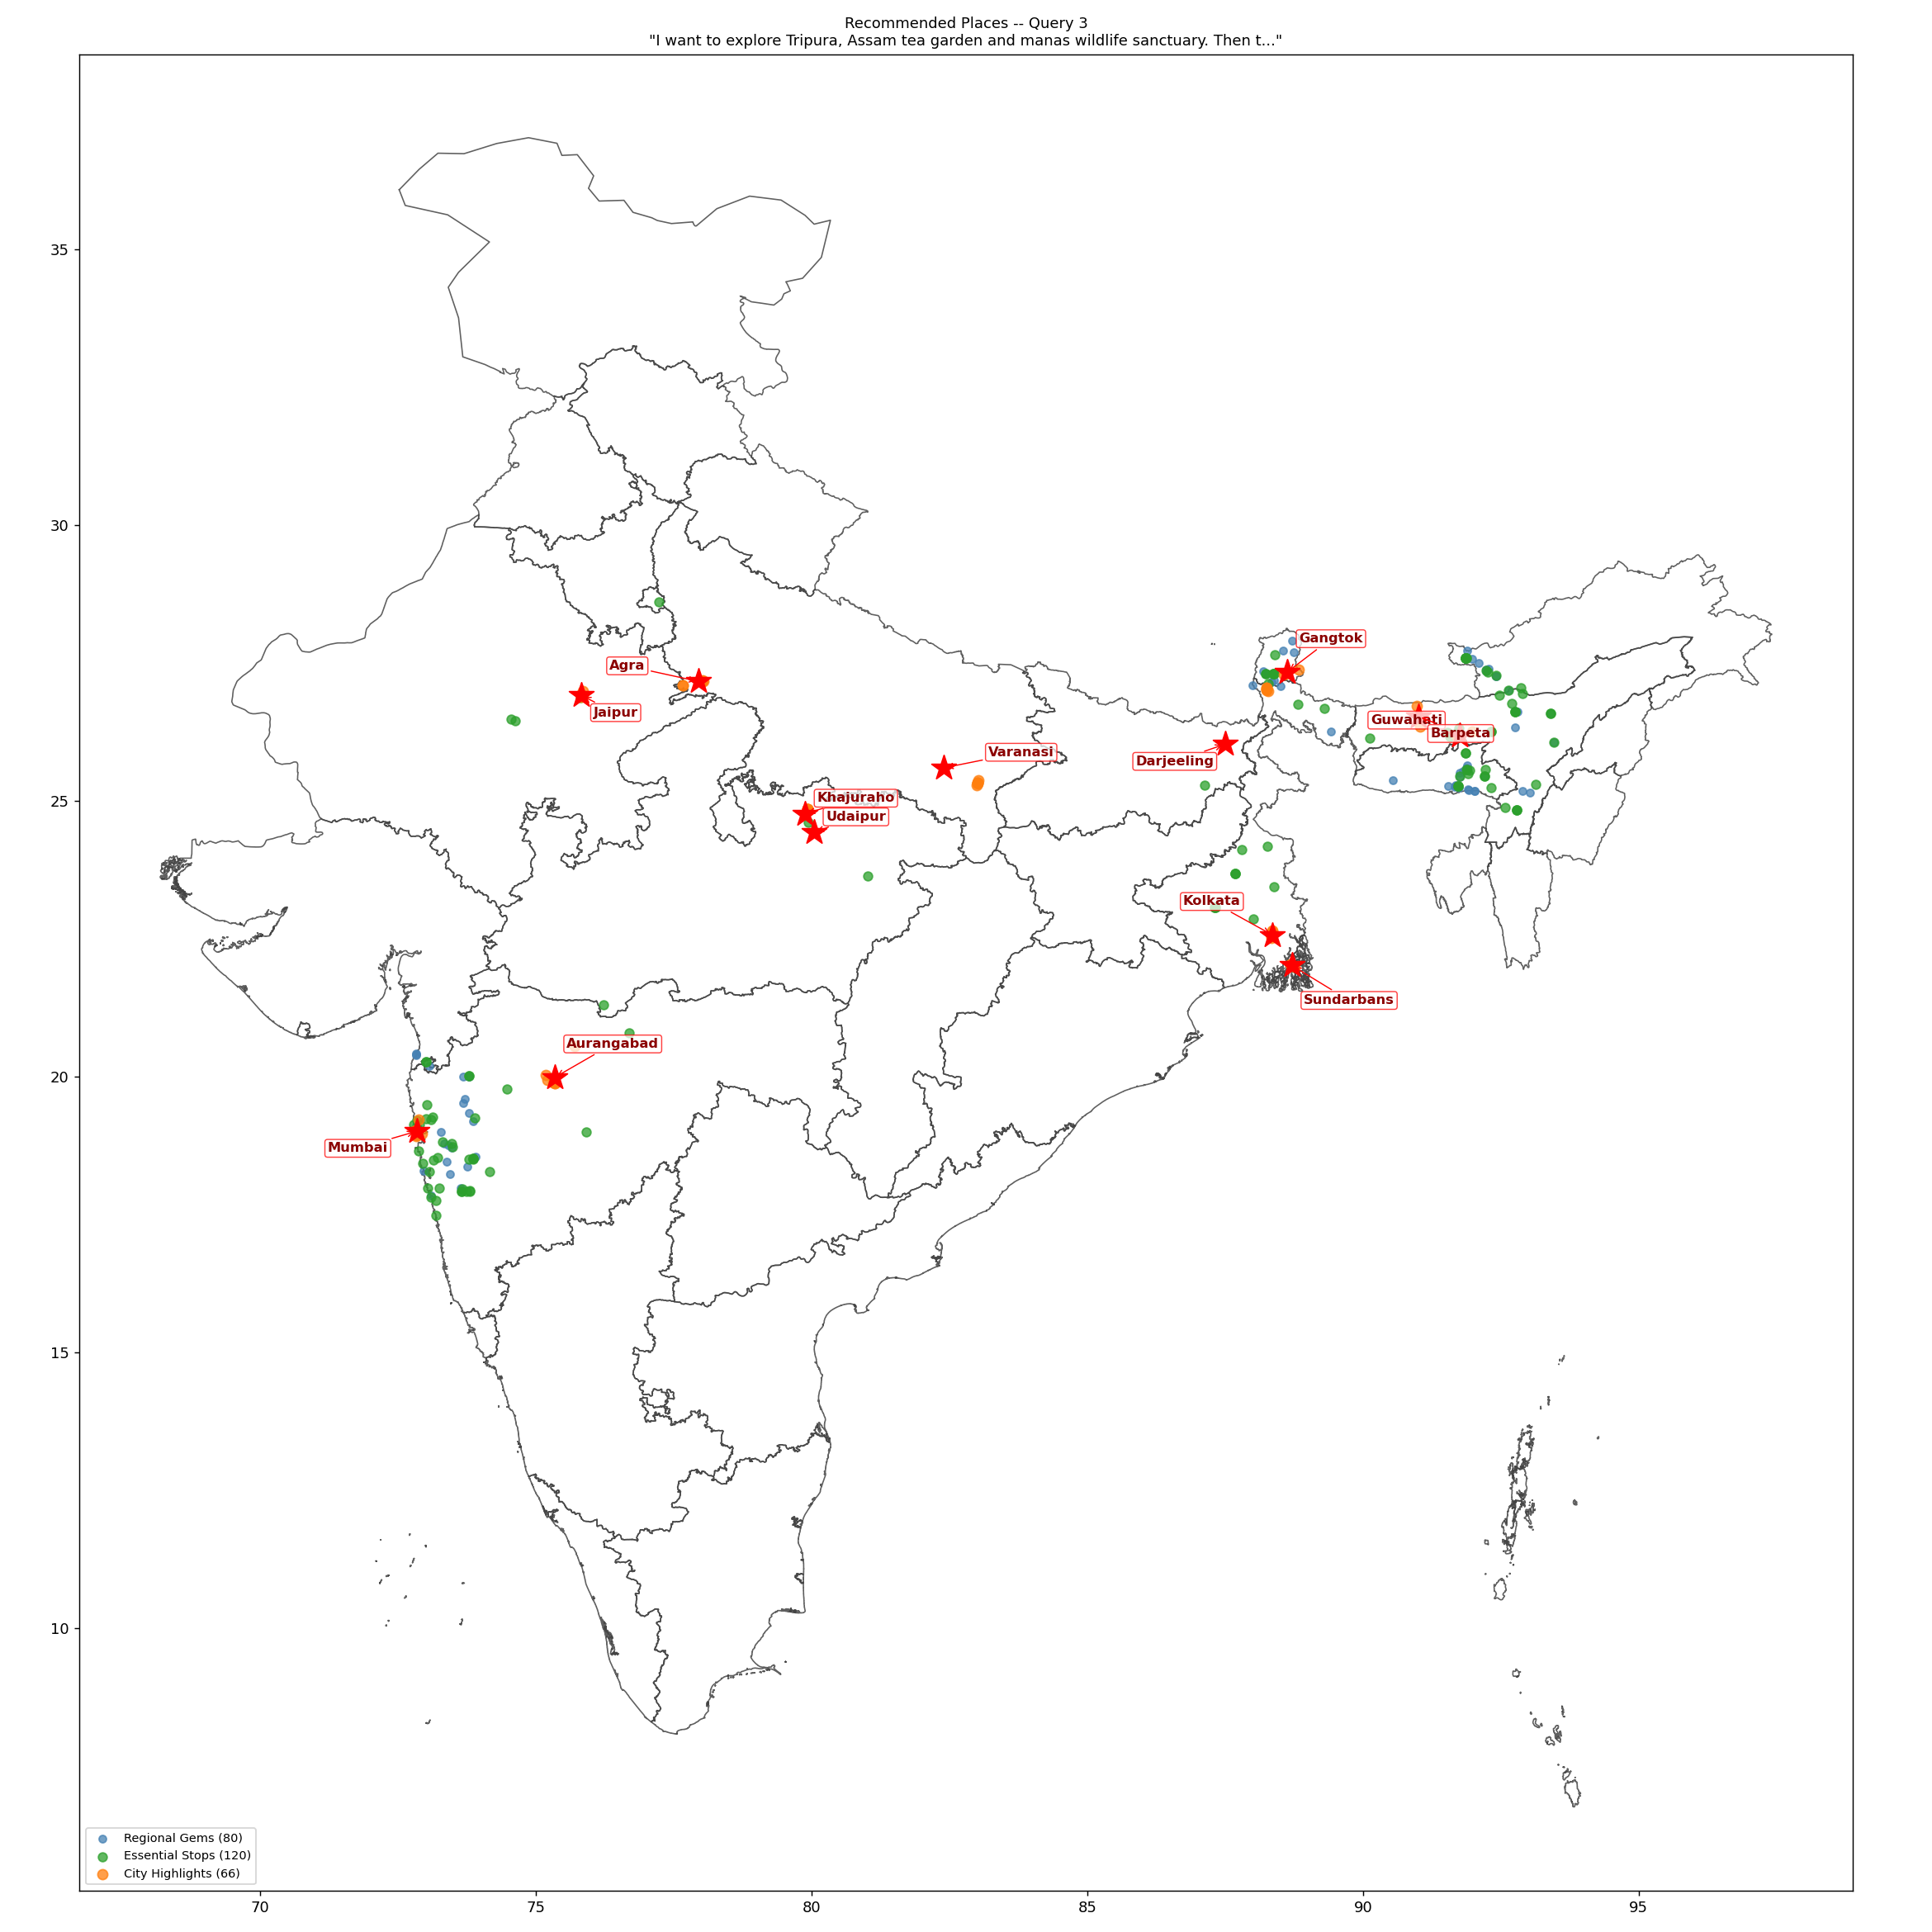

In [1]:
# -*- coding: utf-8 -*-
"""Phase2_NB1_v20.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1bv5t7ejAjfcAnuxMn2cBqzkUeU-yKIHb
"""

# ==============================================================================
# Phase2_NB1_v20 — COMPLETE NOTEBOOK  (Google Colab)
# CELL 1: Imports, Datasets, SLM, Utilities
# ==============================================================================
# v20 Changes summary (over v13):
#   1. POI day allocation: min=2 days per POI (consistent with NB2 v20).
#      - Only applied when travel_days >= 2 * num_pois; falls back to min=1.
#      - Proportional floats clipped to [min, max_alloc], then floor-and-fix
#        so sum == travel_days exactly (distribute remainder to POIs with
#        largest fractional parts; remove excess from smallest fractional parts).
#      - poi_itinerary_segments in NB1 output now reflects the min-2 allocation.
# v13 Changes summary (over v12):
#   1. extract_main_pois: Supports unlimited POIs (no cap at 4). Handles
#      state names (Tripura, Assam -> all cities in state), named park/place
#      names (Ranthambore->Sawai Madhopur, Bandhavgarh->Umaria), and plain
#      city names. POI count scales with trip duration (max days//2, min 4).
#   2. Pool size (get_top_n_for_days): Scales proportionally with num_pois
#      so longer/multi-POI trips get larger candidate pools.
#   3. Anti-flooding guard: When num_pois >= 5, cap city_highlights per POI
#      to avoid excessive fill in one main POI while others are starved.
# v7 Changes summary (preserved):
#   1. POI-Proximity Gravity Score (Approach A):
#      geo_score uses piecewise distance-decay anchored to every main POI;
#      replaces flat geo_affinity_score with a physics-inspired gravity score.
#   2. POI-State Hard Floor (Approach B):
#      same-state places get user_score *1.3 and geo_score +1.5 bonus;
#      scarcity bonus halved for non-POI-state places to prevent Tamil Nadu
#      places from dominating via rare-interest match when POIs are in Kerala.
#   3. Normalized Weighted Aggregation (Approach C, improved):
#      each component normalized 0-1 across the pool, then combined with
#      weights: geo=0.32, interest=0.28, general=0.18, intent=0.10,
#      emotion=0.08, cat_align=0.04. Request score removed. Iconic-ness and
#      SLM geo_fit_score added as post-normalization additive bonuses.
#   4. SLM Re-ranking Reform (Approach D):
#      re-ranker now receives POI names+coordinates; outputs geo_fit_score
#      (0-3) in addition to iconic_bonus; prompt prevents geo-irrelevant
#      places being classified must_visit regardless of attractiveness.
#   5. Pool size scaled by duration: city_highlights=50, essential_stops=55,
#      regional_gems=40 (~40 more places than v6).
#   6. unique_interest places scoring improvement; request score removed from
#      weighted aggregation (logistical signal, not place-quality signal).
# ==============================================================================

import os, json, math, re, statistics
import warnings
from datetime import datetime, timedelta
from collections import defaultdict
import urllib.request
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import logging
import gc, torch

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

print("All imports OK.")

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR        = "/content/drive/MyDrive/travel_planner"
DATA_DIR        = f"{BASE_DIR}/data"
PHASE_1_OUTPUT  = f"{BASE_DIR}/phase_1_output"
OUTPUT_DIR      = f"{BASE_DIR}/phase_2a_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"DATA_DIR       : {DATA_DIR}")
print(f"PHASE_1_OUTPUT : {PHASE_1_OUTPUT}")
print(f"OUTPUT_DIR     : {OUTPUT_DIR}")

# =============================================================================
# A: DATASET LOADING  (unchanged from v6)
# =============================================================================

def load_json(filepath, default=None):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"  [WARN] {filepath} not found -- using default.")
        return default if default is not None else {}

def load_category_mapping(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            raw = f.read()
    except FileNotFoundError:
        print(f"  [WARN] {filepath} not found.")
        return [], {}, {}
    pattern = r'"category"\s*:\s*"([^"]+)"\s*:\s*\{([^{}]+)\}'
    entries, cat_to_intents, cat_to_emotions = [], {}, {}
    for cat_name, body in re.findall(pattern, raw, re.DOTALL):
        intent_m  = re.search(r'"intent"\s*:\s*\[([^\]]+)\]', body)
        emotion_m = re.search(r'"emotion"\s*:\s*\[([^\]]+)\]', body)
        intents  = [v.strip().strip('"') for v in intent_m.group(1).split(',')]  if intent_m  else []
        emotions = [v.strip().strip('"') for v in emotion_m.group(1).split(',')]  if emotion_m else []
        entries.append({"category": cat_name, "intent": intents, "emotion": emotions})
        cat_to_intents[cat_name.lower()]  = {i.lower() for i in intents}
        cat_to_emotions[cat_name.lower()] = {e.lower() for e in emotions}
    return entries, cat_to_intents, cat_to_emotions

def parse_duration_minutes(s):
    if not s:
        return 90
    s = str(s).lower().strip()
    if s in ('full day', 'full-day', 'fullday'):
        return 300
    if 'full day' in s and not re.search(r'\d', s):
        return 300
    if 'half day' in s:
        return 180
    d = re.search(r'(\d+)\s*-?\s*(\d*)\s*day', s)
    if d:
        lo, hi = int(d.group(1)), (int(d.group(2)) if d.group(2) else int(d.group(1)))
        return int(((lo + hi) / 2) * 300)
    h = re.search(r'(\d+)\s*-?\s*(\d*)\s*hour', s)
    if h:
        lo, hi = int(h.group(1)), (int(h.group(2)) if h.group(2) else int(h.group(1)))
        return int(((lo + hi) / 2) * 60)
    m = re.search(r'(\d+)\s*-?\s*(\d*)\s*min', s)
    if m:
        lo, hi = int(m.group(1)), (int(m.group(2)) if m.group(2) else int(m.group(1)))
        return int((lo + hi) / 2)
    return 90

def load_all_datasets():
    print("Loading datasets...")
    attractions_raw  = load_json(f"{DATA_DIR}/attractions.json",      {})
    city_aliases     = load_json(f"{DATA_DIR}/city_aliases.json",     {})
    emotion_data     = load_json(f"{DATA_DIR}/emotion.json",          [])
    intent_data      = load_json(f"{DATA_DIR}/intent.json",           [])
    handicrafts_data = load_json(f"{DATA_DIR}/handicrafts.json",      [])
    request_data     = load_json(f"{DATA_DIR}/request.json",          [])
    category_mapping, cat_to_intents, cat_to_emotions = load_category_mapping(
        f"{DATA_DIR}/category_mapping.json")

    all_attractions = []
    def extract_attractions(data, current_region=""):
        if isinstance(data, dict):
            if "place" in data and "city" in data:
                for coord in ('latitude', 'longitude'):
                    try:
                        data[coord] = float(data.get(coord, -90.0) or -90.0)
                    except (ValueError, TypeError):
                        data[coord] = -90.0
                if 'region' not in data and current_region:
                    data['region'] = current_region
                all_attractions.append(data)
            else:
                for key, val in data.items():
                    pass_region = key if "india" in key.lower() else current_region
                    extract_attractions(val, pass_region)
        elif isinstance(data, list):
            for item in data:
                extract_attractions(item, current_region)
    extract_attractions(attractions_raw)

    handicraft_by_place, handicraft_by_state, handicraft_spatial = {}, defaultdict(list), []
    for h in handicrafts_data:
        key = h.get('PlaceName', '').lower()
        if key: handicraft_by_place[key] = h
        state = h.get('State', '').lower()
        if state: handicraft_by_state[state].append(h)
        try:
            h_lat = float(h.get('latitude',  0) or 0)
            h_lon = float(h.get('longitude', 0) or 0)
        except (ValueError, TypeError):
            h_lat = h_lon = 0.0
        if h_lat and h_lon:
            handicraft_spatial.append((h_lat, h_lon, h))

    emotion_kw_map, intent_kw_map, request_kw_map = {}, {}, {}
    for obj in emotion_data:
        emo = obj.get('emotion', '').lower()
        if emo: emotion_kw_map[emo] = [k.lower() for k in obj.get('keywords', [])]
    for obj in intent_data:
        nm = obj.get('intent', '').lower()
        if nm: intent_kw_map[nm] = [k.lower() for k in obj.get('keywords', [])]
    for obj in request_data:
        nm = obj.get('request', '').lower()
        if nm: request_kw_map[nm] = [k.lower() for k in obj.get('keywords', [])]

    print(f"  Attractions loaded   : {len(all_attractions)}")
    print(f"  City aliases         : {len(city_aliases)}")
    print(f"  Category mappings    : {len(category_mapping)}")
    print(f"  Emotion entries      : {len(emotion_kw_map)}")
    print(f"  Intent entries       : {len(intent_kw_map)}")
    print(f"  Request entries      : {len(request_kw_map)}")
    print(f"  Handicraft entries   : {len(handicraft_by_place)}")
    return (all_attractions, city_aliases, category_mapping,
            emotion_kw_map, intent_kw_map, request_kw_map,
            handicraft_by_place, handicraft_by_state,
            cat_to_intents, cat_to_emotions, handicraft_spatial)

# =============================================================================
# B1: HANDICRAFT SPATIAL LOOKUP HELPERS (unchanged from v6)
# =============================================================================

def get_handicrafts_within_radius(lat, lon, handicraft_spatial, radius_km=5.0):
    return [h for h_lat, h_lon, h in handicraft_spatial
            if haversine(lat, lon, h_lat, h_lon) <= radius_km]

def format_handicraft_info(h_list):
    crafts, folk_music, folk_perf = set(), set(), set()
    for h in h_list:
        for item in str(h.get('Handicraft', '') or '').split('|'):
            v = item.strip()
            if v: crafts.add(v)
        for item in str(h.get('Tribal Handicraft', '') or '').split('|'):
            v = item.strip()
            if v: crafts.add(v)
        for item in str(h.get('Folk Music', '') or '').split('|'):
            v = item.strip()
            if v: folk_music.add(v)
        for item in str(h.get('Folk Performance', '') or '').split('|'):
            v = item.strip()
            if v: folk_perf.add(v)
    parts = []
    if crafts:      parts.append(f"Handicrafts: {', '.join(sorted(crafts))}")
    if folk_music:  parts.append(f"Folk Music: {', '.join(sorted(folk_music))}")
    if folk_perf:   parts.append(f"Folk Performance: {', '.join(sorted(folk_perf))}")
    return ' | '.join(parts)

def query_mentions_art(record):
    combined = (record.get('query', '') + ' ' +
                ' '.join(str(i) for i in record.get('interests', []))).lower()
    art_root_tokens = {'handicraft', 'craft', 'folk', 'textile', 'weav', 'pottery',
                       'tribal', 'art', 'music', 'dance', 'perform'}
    for tok in combined.replace(',', ' ').split():
        if any(root in tok for root in art_root_tokens): return True
    for kw_list in record.get('_interest_expansion', {}).values():
        for kw in kw_list:
            if any(root in kw for root in art_root_tokens): return True
    for tok in record.get('_must_have_tokens', []):
        if any(root in tok for root in art_root_tokens): return True
    return False

def extract_named_art_types(record):
    combined = (record.get('query', '') + ' ' +
                ' '.join(str(i) for i in record.get('interests', []))).lower()
    named_art_vocab = record.get('_named_art_vocab', set())
    if isinstance(named_art_vocab, list): named_art_vocab = set(named_art_vocab)
    if named_art_vocab:
        return {art for art in named_art_vocab if art in combined}
    found = set()
    art_root_tokens = {'craft', 'folk', 'textile', 'weav', 'pottery', 'tribal',
                       'dance', 'music', 'perform', 'painting', 'print', 'carving'}
    for kw_list in record.get('_interest_expansion', {}).values():
        for kw in kw_list:
            kw_l = kw.lower()
            if any(root in kw_l for root in art_root_tokens) and kw_l in combined:
                found.add(kw_l)
    return found

# =============================================================================
# B: SLM INITIALIZATION (unchanged from v6)
# =============================================================================

def init_slm():
    print("Loading Phi-3-mini model...")
    model_id  = "microsoft/Phi-3-mini-4k-instruct"
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model     = AutoModelForCausalLM.from_pretrained(
        model_id, device_map="cuda", dtype=torch.float16)
    p = pipeline("text-generation", model=model, tokenizer=tokenizer,
                 return_full_text=False, use_cache=True)
    print("  Model ready.")
    return p

def query_slm(pipe, system_msg, user_msg, max_new_tokens=150):
    messages = [{"role": "system", "content": system_msg},
                {"role": "user",   "content": user_msg}]
    prompt = pipe.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        outputs = pipe(prompt, do_sample=False, max_new_tokens=max_new_tokens,
                       pad_token_id=pipe.tokenizer.eos_token_id,
                       temperature=None, top_p=None)
    return outputs[0]["generated_text"].strip()

def safe_parse_json(text, fallback):
    clean = text.replace("```json", "").replace("```", "").strip()
    for pattern in [r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)?\\}', r'\[[^\[\]]*\]',
                    r'\{.*?\}', r'\[.*?\]']:
        m = re.search(pattern, clean, re.DOTALL)
        if m:
            try: return json.loads(m.group())
            except json.JSONDecodeError: continue
    return fallback

# =============================================================================
# C: UTILITY FUNCTIONS (unchanged from v6 except get_top_n_for_days)
# =============================================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def cross_track_distance(p_lat, p_lon, a_lat, a_lon, b_lat, b_lon):
    R_KM = 6371.0
    lat_scale = math.radians(1) * R_KM
    lon_scale  = math.radians(1) * R_KM * math.cos(math.radians((a_lat + b_lat) / 2))
    bx = (b_lon - a_lon) * lon_scale;  by = (b_lat - a_lat) * lat_scale
    px = (p_lon - a_lon) * lon_scale;  py = (p_lat - a_lat) * lat_scale
    seg_len_sq = bx*bx + by*by
    if seg_len_sq == 0.0: return math.sqrt(px*px + py*py)
    t = max(0.0, min(1.0, (px*bx + py*by) / seg_len_sq))
    dx, dy = px - t*bx, py - t*by
    return math.sqrt(dx*dx + dy*dy)

def get_radius_km(days, num_pois=1):
    if days <= 1:   base = 250
    elif days == 2: base = 375
    elif days == 3: base = 500
    elif days == 4: base = 625
    elif days == 5: base = 750
    elif days == 6: base = 875
    elif days == 7: base = 1000
    else:           base = min(1000 + (days - 7) * 50, 3000)
    return max(150, base // max(1, num_pois))

def get_top_n_for_days(days, num_pois=1):
    """
    v13: Pool size scales with both duration AND number of POIs.
    For multi-POI trips (e.g. 25 days, 13 POIs), each bucket is expanded
    proportionally so every POI gets adequate candidate coverage.
    Formula: base = max(12, days * 5) * min(2.5, 1 + 0.12*(num_pois-1))
    Caps: city_highlights=80, essential_stops=120, regional_gems=80.
    """
    _poi_scale   = min(2.5, 1.0 + 0.12 * max(0, num_pois - 1))
    base         = int(max(12, days * 5) * _poi_scale)
    must_visit_q = max(base, int(days * 3 * max(1, num_pois) * min(1.5, _poi_scale)))
    return {
        "city_highlights":  min(base,          80),
        "essential_stops":  min(must_visit_q, 120),
        "regional_gems":    min(base,          80),
    }
def detect_region_constraint(record, all_attractions):
    query_lower = record.get('query', '').lower()
    known_regions = set()
    for place in all_attractions:
        r = place.get('region', '')
        if r: known_regions.add(r)
    matched_regions = set()
    for region in known_regions:
        if region.lower() in query_lower: matched_regions.add(region)
    if not matched_regions and record.get('places'):
        poi_regions = set()
        for place_name in record.get('places', []):
            for attr in all_attractions:
                if attr.get('city', '').lower() == place_name.lower():
                    r = attr.get('region', '')
                    if r: poi_regions.add(r)
                    break
        if len(poi_regions) == 1: matched_regions = poi_regions
    if len(matched_regions) == 1: return matched_regions.pop()
    return None

# =============================================================================
# D: POI EXTRACTION
# =============================================================================

def extract_main_pois(record, all_attractions, city_aliases, pipe):
    """
    v21 POI extraction — all v13/v20 behaviour preserved + state-disambiguation fix.

    Key changes from v13/v20:
    - No hard cap at 4 POIs; cap scales with duration (max duration_days//2, min 4).
    - State names (e.g. "Tripura", "Assam") resolve to their most-visited city
      (highest attraction count) within that state.
    - Named place names (e.g. "Ranthambore", "Bandhavgarh", "Manas Wildlife Sanctuary")
      resolve to their host city via place-name matching in attractions dataset.
    - Named places that are specific destinations (not just a host city) are flagged
      with `is_specific_place=True` so routing/scoring can force a visit there
      rather than just exploring the surrounding region.
    - SLM fallback extended to ask for more cities when duration is long.
    - Anti-duplication: same city from multiple source names is collapsed.

    FIX (v21): Cross-state centroid pollution eliminated.
    ----------------------------------------------------------
    Root cause: the old Pass 1 / Pass 2 keyed valid_cities_dict on city_lower alone.
    When a city name (e.g. "udaipur") appears in two states (Rajasthan and Tripura),
    the first-seen state's name was stored but ALL states' coordinates were
    accumulated, placing the centroid roughly in Madhya Pradesh — far from either
    real city. Four affected city names in the current dataset:
        udaipur    → Rajasthan (13) vs Tripura (9)   → canonical: Rajasthan
        deoghar    → Jharkhand (5)  vs Bihar (1)      → canonical: Jharkhand
        bishnupur  → West Bengal (8)  vs Manipur (2)  → canonical: West Bengal
        dharmapuri → Tamil Nadu (1)  vs Telangana (1) → canonical: Tamil Nadu (first alpha)

    Fix strategy:
    1. Internally accumulate coords and counts keyed on (city_lower, state_lower).
    2. For each city name that exists in multiple states, elect the canonical state
       as the one with the highest attraction count (tie → first alphabetically).
    3. valid_cities_dict (used for direct city-name lookups) registers only the
       canonical (winning) state entry for each city name.
    4. state_to_cities_dict is still populated for ALL (city, state) combos, so
       _best_city_for_state("tripura") correctly returns Udaipur-Tripura with a
       Tripura-only centroid — no breakage to state-expansion logic.
    """
    raw_places      = record.get('places', [])
    query_text      = record.get('query', '')
    intent          = record.get('intent', '')
    interests       = record.get('interests', [])
    emotions        = record.get('emotion', [])
    requests        = record.get('request', [])
    duration_days   = record.get('duration_days', 7) or 7

    # Max POIs scales with trip length; min 4, max duration//2 (capped at 20)
    max_pois = max(4, min(20, duration_days // 2))

    # -------------------------------------------------------------------------
    # Build lookup structures
    # FIX: accumulate per (city_lower, state_lower) to avoid cross-state merging
    # -------------------------------------------------------------------------

    # Step 1: accumulate coords and counts keyed on (city_lower, state_lower)
    _city_state_data = {}   # (city_lower, state_lower) -> info dict
    for attr in all_attractions:
        city  = attr.get('city')
        state = attr.get('state', '').strip()
        if not city or attr.get('latitude', -90.0) == -90.0:
            continue
        city_lower  = city.lower()
        state_lower = state.lower()
        try:
            lat = float(attr['latitude'])
            lon = float(attr['longitude'])
        except (TypeError, ValueError):
            continue

        key = (city_lower, state_lower)
        if key not in _city_state_data:
            _city_state_data[key] = {
                "city": city, "state": state, "state_lower": state_lower,
                "region": attr.get('region', ''), "is_specific_place": False,
                "_attraction_count": 0, "_coords": [],
            }
        _city_state_data[key]["_attraction_count"] += 1
        _city_state_data[key]["_coords"].append((lat, lon))

    # Step 2: for each city name, elect the canonical state
    # (most attractions; alphabetical tie-break for determinism)
    _city_best_state = {}   # city_lower -> winning state_lower
    for (city_lower, state_lower), info in _city_state_data.items():
        prev = _city_best_state.get(city_lower)
        if prev is None:
            _city_best_state[city_lower] = state_lower
        else:
            prev_count = _city_state_data[(city_lower, prev)]["_attraction_count"]
            cur_count  = info["_attraction_count"]
            if cur_count > prev_count or (cur_count == prev_count and state_lower < prev):
                _city_best_state[city_lower] = state_lower

    # Step 3: build valid_cities_dict and state_to_cities_dict from per-(city,state) data
    valid_cities_dict = {}       # city_lower -> city_info  (canonical state only)
    state_to_cities_dict = {}    # state_lower -> {city_lower -> city_info}

    for (city_lower, state_lower), info in _city_state_data.items():
        coords = info["_coords"]
        centroid_lat = sum(c[0] for c in coords) / len(coords)
        centroid_lon = sum(c[1] for c in coords) / len(coords)

        city_entry = {
            "city":              info["city"],
            "state":             info["state"],
            "latitude":          centroid_lat,
            "longitude":         centroid_lon,
            "region":            info["region"],
            "is_specific_place": False,
            "_attraction_count": info["_attraction_count"],
        }

        # state_to_cities_dict gets every (city, state) combo so state-expansion works
        state_to_cities_dict.setdefault(state_lower, {})[city_lower] = city_entry

        # valid_cities_dict gets only the canonical (winning) state per city name
        if _city_best_state.get(city_lower) == state_lower:
            valid_cities_dict[city_lower] = city_entry

    # -------------------------------------------------------------------------
    # Build place-name → city lookup (for named places like Ranthambore, Bandhavgarh)
    # -------------------------------------------------------------------------
    place_name_to_city = {}  # place_lower -> city_info with is_specific_place=True
    for attr in all_attractions:
        pname = attr.get('place', '').lower().strip()
        city  = attr.get('city', '')
        if pname and city and attr.get('latitude', -90.0) != -90.0:
            city_lower = city.lower()
            if city_lower in valid_cities_dict and pname not in place_name_to_city:
                # Create a copy flagged as specific place
                info = dict(valid_cities_dict[city_lower])
                info['is_specific_place']     = True
                info['specific_place_name']   = attr.get('place', '')
                info['specific_place_lat']    = attr['latitude']
                info['specific_place_lon']    = attr['longitude']
                place_name_to_city[pname] = info

    def _best_city_for_state(state_lower):
        """Return the city with most attractions in the given state."""
        cities = state_to_cities_dict.get(state_lower, {})
        if not cities:
            return None
        return max(cities.values(), key=lambda c: c.get('_attraction_count', 0))

    def resolve_and_lookup(name):
        """
        Resolve a name to a POI dict. Tries in order:
        1. Direct city alias lookup
        2. State name -> best city in state
        3. Place name substring match in attractions
        4. Fuzzy city name match
        Returns (poi_dict, is_state_expansion) tuple.
        """
        n = name.strip()
        canonical = city_aliases.get(n.title(), city_aliases.get(n, n.title()))
        key = canonical.lower()

        # 1. Direct city match
        if key in valid_cities_dict:
            return valid_cities_dict[key], False

        # 2. State name match -> best city in state
        n_lower = n.lower()
        if n_lower in state_to_cities_dict:
            best = _best_city_for_state(n_lower)
            if best:
                return best, True  # True = came from state expansion

        # 3. Named place match (e.g. "Ranthambore", "Bandhavgarh National Park")
        # First try exact place name
        if n_lower in place_name_to_city:
            return place_name_to_city[n_lower], False
        # Then try substring match
        for pname, pinfo in place_name_to_city.items():
            if n_lower in pname or pname in n_lower:
                return pinfo, False

        # 4. Regex city name match in attractions
        pat = re.compile(rf'\b{re.escape(n_lower)}\b')
        for attr in all_attractions:
            if pat.search(attr.get('place', '').lower()):
                mapped = attr.get('city', '').lower()
                if mapped in valid_cities_dict:
                    return valid_cities_dict[mapped], False

        return None, False

    main_pois, seen = [], set()

    # --- Resolve raw_places[] ---
    if raw_places:
        for p in raw_places:
            if len(main_pois) >= max_pois:
                break
            poi, _from_state = resolve_and_lookup(p)
            if poi:
                city_lower = poi['city'].lower()
                if city_lower not in seen:
                    main_pois.append(dict(poi))
                    seen.add(city_lower)
            else:
                print(f"  [INFO] '{p}' not matched in attractions. Using manual override.")
                manual_poi = {
                    "city": p, "state": "Unknown",
                    "latitude": 20.5937, "longitude": 78.9629,
                    "region": "Unknown", "is_specific_place": False,
                }
                if p.lower() not in seen:
                    main_pois.append(manual_poi)
                    seen.add(p.lower())

    # --- SLM fallback if raw_places empty or produced nothing ---
    if not main_pois:
        valid_city_names = sorted([d['city'] for d in valid_cities_dict.values()])
        valid_cities_str = ", ".join(valid_city_names)
        slm_max_cities   = max(4, min(max_pois, duration_days // 2))
        print(f"  [INFO] places[] is empty -- asking SLM (max {slm_max_cities} cities)...")
        system_msg = (
            "You are an expert Indian travel planner.\n"
            "RULES:\n"
            f"1. Select 1-{slm_max_cities} cities ONLY from the VALID CITIES LIST.\n"
            "2. Map attractions to host cities (e.g. Ranthambore -> Sawai Madhopur).\n"
            "3. Use intent, interests, emotions, and requests to infer destinations.\n"
            "4. For longer trips, suggest more cities proportionally.\n"
            "5. Output ONLY a raw JSON array. No markdown."
        )
        user_msg = (
            f"VALID CITIES: {valid_cities_str}\n\n"
            f"Query: \"{query_text}\"\n"
            f"Intent: {intent} | Interests: {interests}\n"
            f"Emotions: {emotions} | Requests: {requests}\n"
            f"Trip duration: {duration_days} days\n\n"
            f"Return JSON array of 1-{slm_max_cities} city names:"
        )
        slm_resp  = query_slm(pipe, system_msg, user_msg, max_new_tokens=120)
        slm_locs  = safe_parse_json(slm_resp, [])
        if isinstance(slm_locs, list):
            for loc in slm_locs:
                if len(main_pois) >= max_pois or not isinstance(loc, str):
                    break
                poi, _ = resolve_and_lookup(loc)
                if poi and poi['city'].lower() not in seen:
                    main_pois.append(dict(poi))
                    seen.add(poi['city'].lower())

    # --- Text-scan fallback ---
    if not main_pois:
        q_lower = query_text.lower()
        for city_lower, data in valid_cities_dict.items():
            if re.search(rf'\b{re.escape(city_lower)}\b', q_lower):
                main_pois.append(data)
                if len(main_pois) >= max_pois:
                    break

    # Log any specific-place POIs
    for poi in main_pois:
        if poi.get('is_specific_place'):
            print(f"  [POI] '{poi.get('specific_place_name', poi['city'])}' "
                  f"-> host city: {poi['city']} (will enforce specific-place visit)")

    return main_pois

# =============================================================================
# E: PRE-COMPUTATION HELPERS (unchanged from v6)
# =============================================================================

def _get_interest_expansion(record, pipe):
    interests_lower = [i.lower() for i in record.get('interests', [])]
    if not interests_lower: return {}
    expansion = {}
    if pipe is not None:
        try:
            sys_msg = ("You are a travel keyword expander for an Indian travel planning system. "
                       "Given a list of travel interests, return a JSON object where EVERY key "
                       "is one of the provided interests (lowercase, exact match) and each value "
                       "is an array of 4-10 short English phrases (1-4 words each) that describe "
                       "real Indian places, attractions, or experiences matching that interest. "
                       "Only include phrases that genuinely match the interest -- do NOT cross-contaminate "
                       "(e.g. do not add 'spice market' under 'backwaters'). "
                       "Focus on Indian contexts. "
                       "Return ONLY raw JSON with no markdown, no preamble, no extra keys.")
            user_msg = (f"Interests to expand: {interests_lower}\n"
                        "Return a JSON object with each interest as a key and an array of keyword phrases as the value.")
            response = query_slm(pipe, sys_msg, user_msg, max_new_tokens=400)
            slm_result = safe_parse_json(response, {})
            if isinstance(slm_result, dict):
                for k, v in slm_result.items():
                    if isinstance(v, list):
                        expansion[k.lower()] = [str(x).lower() for x in v if x]
        except Exception as e:
            print(f"  [WARN] Interest expansion SLM call failed: {e}")
    for interest in interests_lower:
        if interest not in expansion:
            tokens = [t.strip() for t in interest.replace('-', ' ').split() if len(t.strip()) > 2]
            expansion[interest] = [interest] + tokens
    return expansion

def _build_category_kw_map(all_attractions, record, pipe):
    dataset_cats = set()
    for place in all_attractions:
        cat = place.get('category', '').lower().strip()
        if cat: dataset_cats.add(cat)
    query_combined = (record.get('query', '') + ' ' +
                      ' '.join(str(i) for i in record.get('interests', []))).lower()
    relevant_cats = {cat for cat in dataset_cats
                     if any(tok in query_combined
                            for tok in cat.replace('_', ' ').split() if len(tok) > 3)}
    if not relevant_cats: relevant_cats = dataset_cats
    cat_kw_map = {}
    if pipe is not None and relevant_cats:
        try:
            sys_msg = ("You are a travel category keyword expander for an Indian travel system. "
                       "Given a list of attraction category names, return a JSON object where "
                       "each key is a category name (exact, lowercase) and the value is an array "
                       "of 4-8 short English keyword phrases (1-3 words) that tourists would use "
                       "when searching for or describing that category. "
                       "Focus on Indian travel context. "
                       "Return ONLY raw JSON -- no markdown, no preamble.")
            user_msg = (f"Categories: {sorted(relevant_cats)}\n"
                        f"Query context: {query_combined[:200]}\n"
                        "Return JSON object mapping each category to keyword phrases.")
            response = query_slm(pipe, sys_msg, user_msg, max_new_tokens=500)
            parsed = safe_parse_json(response, {})
            if isinstance(parsed, dict):
                for k, v in parsed.items():
                    if isinstance(v, list):
                        cat_kw_map[k.lower()] = [str(x).lower() for x in v if x]
        except Exception as e:
            print(f"  [WARN] Category KW map SLM failed: {e}")
    for cat in relevant_cats:
        if cat not in cat_kw_map:
            tokens = [t for t in cat.replace('_', ' ').split() if len(t) > 2]
            cat_kw_map[cat] = [cat.replace('_', ' ')] + tokens
    return cat_kw_map

def _build_must_have_tokens(record, all_attractions, pipe):
    tokens = set()
    for interest in record.get('interests', []):
        i_lower = str(interest).lower().strip()
        if i_lower:
            tokens.add(i_lower)
            for tok in i_lower.replace('-', ' ').split():
                if len(tok) > 3: tokens.add(tok)
    for kw_list in record.get('_interest_expansion', {}).values():
        for kw in kw_list:
            if kw and len(kw) > 3: tokens.add(kw.lower())
    interest_tokens = {tok for i in record.get('interests', [])
                       for tok in str(i).lower().split() if len(tok) > 3}
    for place in all_attractions[:500]:
        pname = place.get('place', '').lower()
        pdesc = place.get('place_desc', '').lower()
        ptext = pname + ' ' + pdesc
        if any(tok in ptext for tok in interest_tokens):
            words = pname.split()
            for j in range(len(words)):
                if len(words[j]) > 3: tokens.add(words[j])
                if j < len(words) - 1:
                    bigram = words[j] + ' ' + words[j+1]
                    if len(bigram) > 6: tokens.add(bigram)
    return sorted(tokens)

def _build_named_art_vocab(handicraft_by_place, handicraft_by_state, handicraft_spatial):
    vocab = set()
    all_hc = list(handicraft_by_place.values())
    for hc_list in handicraft_by_state.values(): all_hc.extend(hc_list)
    for _, _, h in handicraft_spatial: all_hc.append(h)
    for h in all_hc:
        for field in ('Handicraft', 'Tribal Handicraft', 'Folk Music', 'Folk Performance'):
            val = str(h.get(field, '') or '')
            for item in val.split('|'):
                item_clean = item.strip().lower()
                if item_clean and item_clean not in {'none', 'nan', 'null', 'n/a', 'na', ''}:
                    vocab.add(item_clean)
                    for word in item_clean.split():
                        if len(word) > 4: vocab.add(word)
    return vocab

# =============================================================================
# F: v7 GEOGRAPHIC SCORE (Approach A + B)
# =============================================================================

def _compute_geo_score_v7(place, distance_km, max_radius_km, main_pois,
                           poi_cities, region_constraint, record):
    """
    v7 POI-Proximity Gravity Score (Approach A) + POI-State Hard Floor (Approach B).

    Approach A: distance-decay gravity anchored to each POI.
      - Within 10km of POI: full score (1.0)
      - 10-30km: decay power 1.5 (sharp near-field)
      - 30-80km: decay power 2.5 (medium-field)
      - Beyond 80km: decay power 4.0 (steep far-field)
      - Score = max contribution across all POIs * 10.0

    Approach B additive adjustments:
      - Same-state as any POI: +1.5 bonus
      - Same-region cross-state within 200km: positive proximity bonus (max +1.5)
      - Same-region cross-state beyond 200km: soft negative penalty (max -2.0)
      - Different region entirely: steep distance-scaled penalty (max -5.0)

    Returns: (geo_score, in_poi_state)
    """
    _place_state  = place.get('state', '').lower()
    _place_region = place.get('region', '').lower()
    _poi_states   = {p.get('state', '').lower() for p in (main_pois or []) if p.get('state')}
    _query_lower  = record.get('query', '').lower()
    _region_mentioned_broadly = (region_constraint and
                                  region_constraint.lower() in _query_lower)

    # Approach A: per-POI gravity contribution
    max_gravity = 0.0
    for poi in (main_pois or []):
        d = haversine(place.get('latitude', 0), place.get('longitude', 0),
                      poi['latitude'], poi['longitude'])
        norm_d = d / max(1.0, max_radius_km)
        if d <= 10:
            g = 1.0
        elif d <= 30:
            g = max(0.0, (1.0 - norm_d) ** 1.5)
        elif d <= 80:
            g = max(0.0, (1.0 - norm_d) ** 2.5)
        else:
            g = max(0.0, (1.0 - norm_d) ** 4.0)
        max_gravity = max(max_gravity, g)

    geo_score = max_gravity * 10.0

    in_poi_state = bool(_place_state and _poi_states and _place_state in _poi_states)

    # Approach B: state-based adjustments
    if in_poi_state:
        geo_score += 1.5
    elif (region_constraint and _place_region and
          _place_region.lower() == region_constraint.lower()):
        # Same broad region (e.g. South India), cross-state
        _CROSS_STATE_THRESHOLD = 200.0
        if distance_km <= _CROSS_STATE_THRESHOLD:
            _max_bonus = 1.0 if _region_mentioned_broadly else 0.5
            _proximity_factor = max(0.05, 1.0 - (distance_km / max_radius_km) ** 1.8)
            geo_score += round(_max_bonus * _proximity_factor, 2)
        else:
            _over = distance_km - _CROSS_STATE_THRESHOLD
            geo_score -= round(min(2.0, _over / 350.0 * 2.0), 2)
    elif _place_state and _poi_states and _place_state not in _poi_states:
        if region_constraint and _place_region.lower() != region_constraint.lower():
            geo_score -= min(5.0, (distance_km / max(1.0, max_radius_km)) * 5.0)

    return round(geo_score, 3), in_poi_state

# =============================================================================
# G: v7 SYMBOLIC SCORING
# =============================================================================

def symbolic_score_place_v7(place, record, distance_km, max_radius_km,
                              cat_to_intents, cat_to_emotions,
                              emotion_kw_map, intent_kw_map,
                              handicraft_by_place, handicraft_by_state,
                              poi_cities, region_constraint, main_pois=None):
    """
    v7 symbolic scorer. Returns score_breakdown dict or None if place excluded.
    Key changes from v6:
    - Uses _compute_geo_score_v7 (gravity + state floor) instead of flat geo_affinity_score
    - Applies POI-state user_score multiplier (Approach B: *1.3 for same-state places)
    - request_score still computed for backward compat but excluded from total_score
    - total_score is a LEGACY placeholder; actual ranking uses normalized weighted
      aggregation in classify_attractions_v7 after all places are scored
    """
    if distance_km > max_radius_km: return None
    if place.get('latitude', -90.0) == -90.0: return None

    place_name = place.get('place', '').lower()
    place_desc = place.get('place_desc', '').lower()
    place_cat  = place.get('category', '').lower()
    place_text = place_name + ' ' + place_desc

    hc = handicraft_by_place.get(place_name, {})
    if not hc:
        place_state = place.get('state', '').lower()
        state_hcs   = handicraft_by_state.get(place_state, [])
        if state_hcs: hc = state_hcs[0]
    if hc:
        place_text += ' ' + ' '.join([
            str(hc.get('Handicraft', '')), str(hc.get('Tribal Handicraft', '')),
            str(hc.get('Folk Music', '')), str(hc.get('Folk Performance', '')),
            str(hc.get('Categorization', '')),
        ]).lower()

    # general_score
    rating = place.get('ratings')
    try:
        rating = float(rating) if rating is not None else 3.0
    except (ValueError, TypeError):
        rating = 3.0
    general_score = rating * 1.5
    is_must_visit = str(place.get('must_visit', 'no')).lower() == 'yes'
    if is_must_visit: general_score += 5.0

    # intent_score
    record_intent  = record.get('intent', '').lower()
    mapped_intents = cat_to_intents.get(place_cat, set())
    intent_score   = 3.0 if record_intent in mapped_intents else 0.0

    # interest_score (same as v6)
    combined_interests = [i.lower() for i in record.get('interests', [])]
    interest_expansion = record.get('_interest_expansion', {})
    if any(kw in record.get('query', '').lower()
           for kw in ('handicraft', 'craft', 'folk', 'textile', 'weaving', 'pottery')):
        if 'arts_crafts_culture' in place_cat or hc:
            combined_interests.append('handicraft')
    interest_score = 0.0
    _matched_interests_for_scarcity = []
    for interest in combined_interests:
        if interest in place_text:
            interest_score += 4.0; _matched_interests_for_scarcity.append(interest); continue
        _matched_exp = False
        for exp_kw in interest_expansion.get(interest, []):
            if exp_kw and exp_kw in place_text:
                interest_score += 4.0; _matched_exp = True
                _matched_interests_for_scarcity.append(interest); break
        if _matched_exp: continue
        _interest_word_tokens = [t for t in interest.replace('-',' ').split() if len(t) > 3]
        if _interest_word_tokens and all(tok in place_text for tok in _interest_word_tokens):
            interest_score += 3.5; _matched_interests_for_scarcity.append(interest); continue
        if any(tok in place_text for tok in _interest_word_tokens):
            interest_score += 1.5; _matched_interests_for_scarcity.append(interest)
    interest_score = min(20.0, interest_score)

    # emotion_score
    emotion_score = 0.0
    for emo in record.get('emotion', []):
        kws = emotion_kw_map.get(emo.lower(), [])
        if any(kw in place_text for kw in kws): emotion_score += 2.0

    # intent_kw_score
    intent_kws      = intent_kw_map.get(record_intent, [])
    intent_kw_score = 1.5 if any(kw in place_text for kw in intent_kws) else 0.0

    # request_score (kept for backward compat; EXCLUDED from v7 weighted aggregation)
    request_score = 0.0
    for req in record.get('request', []):
        req_kws = {}.get(req.lower(), [])  # request_kw_map not in scope here; set 0
        if any(kw in place_text for kw in req_kws): request_score += 1.0
    request_score = min(3.0, request_score)

    # category_align_bonus
    _query_lower = record.get('query', '').lower()
    _interest_lower = ' '.join(str(i).lower() for i in record.get('interests', []))
    _combined_query = _query_lower + ' ' + _interest_lower
    _cat_kw_map = record.get('_category_kw_map', {})
    category_align_bonus = 0.0
    for cat_kw, kw_list in _cat_kw_map.items():
        if any(kw in _combined_query for kw in kw_list):
            if cat_kw in place_cat: category_align_bonus += 3.0
            if any(kw in place_text for kw in kw_list):
                category_align_bonus = min(6.0, category_align_bonus + 2.0)

    # geo_score v7 (Approach A + B)
    geo_score, in_poi_state = _compute_geo_score_v7(
        place, distance_km, max_radius_km, main_pois,
        poi_cities, region_constraint, record)

    # Approach B: POI-state user_score multiplier (+30% for same-state)
    user_score_raw = intent_score + interest_score + emotion_score + intent_kw_score
    # NOTE: request_score intentionally excluded from user_score in v7
    user_score = round(user_score_raw * 1.3 if in_poi_state else user_score_raw, 2)

    # Distance penalty (same as v6, kept for legacy classification)
    _df = distance_km / max(1.0, max_radius_km)
    if _df <= 0.4:
        distance_penalty = round(_df ** 2.2 * 5.0, 2)
    elif _df <= 0.7:
        distance_penalty = round(5.0 + (_df - 0.4) / 0.3 * 5.0, 2)
    else:
        distance_penalty = 12.0

    # Route bonus
    route_bonus = 0.0
    if main_pois and len(main_pois) >= 2:
        min_ct = float('inf')
        for i in range(len(main_pois) - 1):
            ct = cross_track_distance(
                place.get('latitude'), place.get('longitude'),
                main_pois[i]['latitude'],   main_pois[i]['longitude'],
                main_pois[i+1]['latitude'], main_pois[i+1]['longitude'])
            if ct < min_ct: min_ct = ct
        if min_ct <= 30: route_bonus = 2.5
        elif min_ct <= 50: route_bonus = 1.5

    # POI-city boost
    poi_city_boost = 0.0
    if place.get('city', '').lower() in poi_cities:
        _interest_scale = min(1.0, interest_score / 8.0)
        poi_city_boost  = 3.0 + 2.0 * _interest_scale

    # Must-have tokens
    _must_have_tokens_base = record.get('_must_have_tokens', [])
    _interest_tokens = [str(_itm).lower().strip()
                        for _itm in record.get('interests', []) if str(_itm).strip()]
    _all_must_tokens = set(_must_have_tokens_base + _interest_tokens)
    _query_must_match = False
    for _tok in _all_must_tokens:
        if _tok in _combined_query and _tok in place_text:
            _query_must_match = True; break

    # Legacy total_score (for pre-filter classification only; NOT used for final ranking)
    total_score_legacy = (general_score + user_score + route_bonus
                          + poi_city_boost + category_align_bonus
                          + geo_score - distance_penalty)

    # Pre-filter classification (same geo-gate as v6)
    in_poi_city = place.get('city', '').lower() in poi_cities
    _place_state  = place.get('state', '').lower()
    _poi_states   = {p.get('state', '').lower() for p in (main_pois or []) if p.get('state')}
    _same_state   = _place_state in _poi_states if _poi_states else False
    _geo_gate_ok  = _same_state or distance_km <= 200.0

    if in_poi_city and total_score_legacy >= 5.0:
        cls = "main_city"
    elif (_query_must_match or user_score >= 3.0 or category_align_bonus >= 3.0) and _geo_gate_ok:
        cls = "must_visit"
    elif _query_must_match or user_score >= 3.0 or category_align_bonus >= 3.0:
        cls = "other_popular"
    elif is_must_visit or rating >= 4.5 or total_score_legacy >= 5.0:
        cls = "other_popular"
    else:
        cls = "skip"

    return {
        "general_score":       round(general_score,       2),
        "intent_score":        round(intent_score,        2),
        "interest_score":      round(interest_score,      2),
        "emotion_score":       round(emotion_score,       2),
        "intent_kw_score":     round(intent_kw_score,     2),
        "request_score":       round(request_score,       2),  # kept for compat
        "poi_city_boost":      round(poi_city_boost,      2),
        "category_align_bonus":round(category_align_bonus,2),
        "geo_affinity_score":  round(geo_score,           2),  # alias for NB2 compat
        "geo_score":           round(geo_score,           2),  # v7 gravity score
        "iconic_bonus":        0.0,
        "iconic_reason":       "",
        "route_bonus":         round(route_bonus,         2),
        "distance_penalty":    distance_penalty,
        "user_score":          round(user_score,          2),
        "total_score":         round(total_score_legacy,  2),  # legacy; overwritten after normalization
        "classification_suggestion": cls,
        "classification_reason":     "symbolic pre-filter v7",
        "_matched_interests":  _matched_interests_for_scarcity,
        "_in_poi_state":       in_poi_state,
    }

# =============================================================================
# H: v7 NORMALIZED WEIGHTED AGGREGATION (Approach C)
# =============================================================================

# v7 component weights (sum = 1.0, data-driven, not hardcoded per query)
_V7_WEIGHTS = {
    'geo_score':            0.32,  # primary: geographic fit
    'interest_score':       0.28,  # primary: query-specific relevance
    'general_score':        0.18,  # quality (ratings + must_visit)
    'intent_score':         0.10,  # traveler type alignment
    'emotion_score':        0.08,  # mood-based alignment
    'category_align_bonus': 0.04,  # fine-grained category match
    # request_score: intentionally excluded (logistical, not place-quality)
}

def _normalize_component(values):
    """Min-max normalize a list of values to [0, 1]. Returns list."""
    mn, mx = min(values), max(values)
    rng = mx - mn
    if rng == 0: return [0.5] * len(values)
    return [(v - mn) / rng for v in values]

def _normalize_pool_v7(sym_scored):
    """
    Normalize each weighted component across the full scored pool.
    Returns dict: {place_name: {component: normalized_value}}
    """
    components = list(_V7_WEIGHTS.keys())
    pool_vals  = {comp: [p['score_breakdown'].get(comp, 0.0) for p in sym_scored]
                  for comp in components}
    pool_norms = {comp: _normalize_component(pool_vals[comp]) for comp in components}
    result = {}
    for idx, p in enumerate(sym_scored):
        result[p['name']] = {comp: pool_norms[comp][idx] for comp in components}
    return result

def compute_weighted_score_v7(place_name, normalized, score_breakdown,
                               iconic_bonus=0.0, geo_fit_bonus=0.0):
    """
    Compute final v7 score = weighted normalized components + post-normalization bonuses.
    iconic_bonus: 3.0 for world-famous landmarks -> scaled to +0.15
    geo_fit_bonus: SLM geo_fit_score (0-3) -> scaled to +0.0 to +0.15
    poi_city_boost and route_bonus: tiny additive (not normalized)
    """
    norm = normalized.get(place_name, {})
    weighted = sum(_V7_WEIGHTS.get(comp, 0.0) * norm.get(comp, 0.0)
                   for comp in _V7_WEIGHTS)
    _iconic_scaled   = iconic_bonus   / 20.0   # 3.0 -> +0.15
    _geo_fit_scaled  = geo_fit_bonus  / 20.0   # 3.0 -> +0.15
    _poi_boost_norm  = min(0.05, score_breakdown.get('poi_city_boost', 0.0) / 100.0)
    _route_norm      = min(0.02, score_breakdown.get('route_bonus', 0.0) / 125.0)
    return round(weighted + _iconic_scaled + _geo_fit_scaled + _poi_boost_norm + _route_norm, 4)

# =============================================================================
# I: v7 SLM RE-RANKER (Approach D -- POI-aware, geo_fit_score output)
# =============================================================================

def build_rerank_system_prompt_v7(category_mapping, emotion_kw_map, intent_kw_map,
                                   main_pois, current_selection_summary=""):
    """
    v7 re-ranker prompt.
    Key changes from v6:
    - POI names and coordinates passed explicitly so SLM reasons about geo-fit
    - SLM outputs geo_fit_score (0-3) -- independent of attractiveness
    - Prompt prevents bias: high-rated far place = geo_fit_score=0, still beautiful
    - must_visit blocked if geo_fit_score=0 (too far from all POIs)
    - Diversity hint still present (same as v6)
    """
    cat_str    = json.dumps([{"category": c["category"],
                               "intent": c["intent"], "emotion": c["emotion"]}
                              for c in category_mapping], ensure_ascii=False)
    emo_str    = json.dumps({k: v[:6] for k, v in list(emotion_kw_map.items())},
                             ensure_ascii=False)
    intent_str = json.dumps({k: v[:6] for k, v in list(intent_kw_map.items())},
                             ensure_ascii=False)
    poi_str    = json.dumps([{"city": p['city'], "state": p.get('state', ''),
                               "lat": p['latitude'], "lon": p['longitude']}
                              for p in main_pois], ensure_ascii=False)
    diversity_hint = (
        f"\nCURRENT SELECTION SO FAR: {current_selection_summary}\n"
        "If a category is already well-represented (3+ entries), prefer 'other_popular'\n"
        "for new candidates in that same category to improve variety.\n"
        if current_selection_summary else ""
    )
    return f"""You are a travel relevance reranker for an Indian travel planning system.
A symbolic pre-filter has already scored this place. Review it and return adjustments.

MAIN POINTS OF INTEREST (POIs) the traveller WANTS to visit:
{poi_str}

CATEGORY->INTENT+EMOTION (category_mapping.json):
{cat_str}

EMOTION->KEYWORDS sample (emotion.json):
{emo_str}

INTENT->KEYWORDS sample (intent.json):
{intent_str}
{diversity_hint}
RULES:
- iconic_bonus: +3.0 ONLY if this is a world-famous Indian landmark (Taj Mahal, Red Fort,
  Kerala Backwaters, etc.) that a visitor to this region would seriously regret missing.
  Give 0.0 for ordinary attractions. A world-famous place far from all POIs still gets
  iconic_bonus=3.0 but MUST get geo_fit_score=0.
- geo_fit_score: INTEGER 0-3. Rate how well this place serves the traveller's
  stated destination goals (the POIs listed above). This score is INDEPENDENT of
  how interesting or beautiful the place is.
    3 = Place is IN one of the main POI cities, or directly on the natural path between them.
    2 = Place is in the same state as a POI, within reasonable travel distance (<= 150 km).
    1 = Place is near a POI state (cross-border) but adds meaningful variety on the route.
    0 = Place is geographically irrelevant to the stated POIs (wrong state, far away).
  IMPORTANT: A beautiful place far from all POIs should still get geo_fit_score=0.
- classification: must_visit=strongly matches traveller AND geo_fit_score>=1,
  other_popular=famous/interesting but not POI-central, skip=irrelevant.
  DO NOT classify must_visit if geo_fit_score=0 (too far from POIs).
- visit_duration_min: use EXACT value from dataset recommended_duration.
  If unsure, repeat the symbolic_visit_duration passed to you.
- BALANCE: do not over-weight any single signal. High-rated place far from POIs
  = other_popular or skip (with iconic exception above).

Return ONLY this JSON (no other text):
{{"iconic_bonus": <0.0 or 3.0>, "iconic_reason": "<one sentence>",
  "geo_fit_score": <0, 1, 2, or 3>,
  "classification_suggestion": "<must_visit|other_popular|skip>",
  "classification_reason": "<one sentence>",
  "visit_duration_min": <integer>}}"""


def slm_rerank_place_v7(place_item, record, rerank_system_prompt, pipe):
    hc = place_item.get('_hc', {})
    cultural = (f"Handicraft:{hc.get('Handicraft','')}, Folk:{hc.get('Folk Performance','')}"
                if hc else "")
    _scarcity_val = place_item.get('score_breakdown', {}).get('scarcity_bonus', 0.0)
    _overnight    = place_item['visit_duration_min'] >= 1440
    _in_poi_state = place_item.get('score_breakdown', {}).get('_in_poi_state', False)
    _scarcity_note = (
        f"SCARCITY BONUS: {_scarcity_val:.2f} -- this place matches a RARE interest "
        f"(few other places in this radius satisfy it). Classify as must_visit if geo_fit_score>=1.\n"
        if _scarcity_val >= 2.0 else ""
    )
    _overnight_note = (
        "OVERNIGHT STAY: recommended_duration = 24 hours. This is an immersive "
        "overnight experience (e.g. houseboat, backwater cruise). Classify as "
        "must_visit if any interest matches AND geo_fit_score >= 1.\n"
        if _overnight else ""
    )
    user_msg = (
        f"Name: {place_item['name']} | City: {place_item['city']} | Category: {place_item['category']}\n"
        f"Rating: {place_item.get('_rating', 'N/A')} | Must-visit in dataset: {place_item.get('_must_visit','no')}\n"
        f"Description: {place_item.get('_desc','')[:200]}\n"
        f"Cultural: {cultural}\n"
        f"Distance from nearest POI: {place_item['distance_km']} km | In POI state: {_in_poi_state}\n"
        f"Symbolic geo_score: {place_item['score_breakdown'].get('geo_score', 0.0)} | "
        f"interest_score: {place_item['score_breakdown'].get('interest_score', 0.0)} | "
        f"general_score: {place_item['score_breakdown'].get('general_score', 0.0)}\n"
        f"Symbolic visit_duration: {place_item['visit_duration_min']} min "
        f"(dataset recommended_duration: {place_item.get('_recommended_duration','unknown')})\n"
        f"{_scarcity_note}{_overnight_note}"
        f"Traveller: Intent={record.get('intent','')} | "
        f"Interests={record.get('interests',[])} | Emotions={record.get('emotion',[])}\n"
        f"Query: {record.get('query','')[:150]}\n\nReturn the JSON:"
    )
    response = query_slm(pipe, rerank_system_prompt, user_msg, max_new_tokens=180)
    result   = safe_parse_json(response, {})
    if not isinstance(result, dict): result = {}

    _raw_ds_dur  = str(place_item.get('_recommended_duration', '') or '')
    _ds_min_orig = parse_duration_minutes(_raw_ds_dur) if _raw_ds_dur else place_item['visit_duration_min']
    _slm_raw     = int(result.get("visit_duration_min", place_item['visit_duration_min']) or place_item['visit_duration_min'])
    _final_dur   = max(_ds_min_orig, _slm_raw)
    _final_dur   = 1440 if _ds_min_orig >= 1440 else min(720, _final_dur)

    return {
        "iconic_bonus":              float(result.get("iconic_bonus",    0.0)),
        "iconic_reason":             str(result.get("iconic_reason",     "")),
        "geo_fit_score":             int(result.get("geo_fit_score",     0)),
        "classification_suggestion": str(result.get("classification_suggestion",
                                         place_item['slm_classification'])),
        "classification_reason":     str(result.get("classification_reason", "")),
        "visit_duration_min":        _final_dur,
    }

# =============================================================================
# J: v7 SCARCITY BONUS (POI-state-aware, Approach B)
# =============================================================================

def _apply_scarcity_bonuses_v7(sym_scored, record, main_pois):
    """
    v7 scarcity bonus: POI-state-aware.
    Places inside POI state: full bonus.
    Places outside POI state: bonus * 0.5 (halved).
    This prevents Tamil Nadu places from dominating via rare-interest match
    when POIs are in Kerala.
    """
    import math as _math_sc
    interests_lower    = [str(i).lower() for i in record.get('interests', [])]
    interest_expansion = record.get('_interest_expansion', {})
    _poi_states        = {p.get('state', '').lower() for p in (main_pois or []) if p.get('state')}

    _interest_match_counts = {}
    for _sp in sym_scored:
        for _mi in _sp['score_breakdown'].get('_matched_interests', []):
            _interest_match_counts[_mi] = _interest_match_counts.get(_mi, 0) + 1

    if _interest_match_counts:
        print(f"  Interest match counts (scarcity): {_interest_match_counts}")
        for _sp in sym_scored:
            _sb = _sp['score_breakdown']
            _place_state = _sp.get('_state', '').lower()
            _in_poi_state = _place_state in _poi_states if _poi_states else True
            _scarcity_bonus = 0.0
            for _mi in _sb.get('_matched_interests', []):
                _cnt = _interest_match_counts.get(_mi, 1)
                _base_bonus = round(10.0 / _math_sc.sqrt(max(1, _cnt)), 3)
                # Approach B: halve for non-POI-state places
                _scarcity_bonus += _base_bonus if _in_poi_state else _base_bonus * 0.5
            _scarcity_bonus = round(min(12.0, _scarcity_bonus), 2)
            _sb['scarcity_bonus'] = _scarcity_bonus
            # Fold scarcity into interest_score for normalization
            _sb['interest_score_with_scarcity'] = (_sb.get('interest_score', 0.0) +
                                                    _scarcity_bonus)
        sym_scored.sort(key=lambda x: -(x['score_breakdown'].get('total_score', 0) +
                                        x['score_breakdown'].get('scarcity_bonus', 0)))

    # Build unique_interest_places (sole-match interest places)
    _unique_ip = {}
    for _sp in sym_scored:
        for _mi in _sp['score_breakdown'].get('_matched_interests', []):
            if _interest_match_counts.get(_mi, 0) == 1:
                _pn = _sp['name'].lower()
                _unique_ip.setdefault(_pn, [])
                if _mi not in _unique_ip[_pn]:
                    _unique_ip[_pn].append(_mi)
    return _unique_ip

# =============================================================================
# K: classify_attractions v7 -- full hybrid pipeline
# =============================================================================

def classify_attractions(all_attractions, main_pois, record, max_radius_km,
                          category_mapping, emotion_kw_map, intent_kw_map,
                          request_kw_map, handicraft_by_place, handicraft_by_state,
                          cat_to_intents, cat_to_emotions, pipe,
                          handicraft_spatial=None):
    """
    v7 full classification pipeline.
    Stage 1: Symbolic scoring of all candidates (symbolic_score_place_v7)
    Stage 2: POI-state-aware scarcity bonus (_apply_scarcity_bonuses_v7)
    Stage 3: Normalized weighted aggregation (_normalize_pool_v7 + compute_weighted_score_v7)
    Stage 4: SLM re-ranking with geo_fit_score (slm_rerank_place_v7)
    Stage 5: Final sort and bucketing
    """
    poi_cities = {p['city'].lower() for p in main_pois}
    top_n      = get_top_n_for_days(record.get('duration_days', 7), num_pois=len(main_pois))

    nearby_handicraft_spatial = []
    if handicraft_spatial:
        for h_lat, h_lon, h in handicraft_spatial:
            min_d = min(haversine(poi['latitude'], poi['longitude'], h_lat, h_lon)
                        for poi in main_pois)
            if min_d <= max_radius_km:
                nearby_handicraft_spatial.append((h_lat, h_lon, h))
    print(f"  Handicraft locations in radius: {len(nearby_handicraft_spatial)}")

    region_constraint = detect_region_constraint(record, all_attractions)
    if region_constraint:
        print(f"  [INFO] Region constraint: {region_constraint}")

    # Pre-compute SLM expansions (once per query)
    if '_interest_expansion' not in record:
        record['_interest_expansion'] = _get_interest_expansion(record, pipe)
        n_exp = sum(len(v) for v in record['_interest_expansion'].values())
        print(f"  Interest expansion: {len(record['_interest_expansion'])} interests -> {n_exp} keywords")
    if '_category_kw_map' not in record:
        record['_category_kw_map'] = _build_category_kw_map(all_attractions, record, pipe)
        print(f"  Category KW map: {len(record['_category_kw_map'])} categories")
    if '_must_have_tokens' not in record:
        record['_must_have_tokens'] = _build_must_have_tokens(record, all_attractions, pipe)
        print(f"  Must-have tokens: {len(record['_must_have_tokens'])}")
    if '_named_art_vocab' not in record:
        record['_named_art_vocab'] = sorted(
            _build_named_art_vocab(handicraft_by_place, handicraft_by_state,
                                   handicraft_spatial or []))
        print(f"  Named art vocab: {len(record['_named_art_vocab'])} terms")

    # STAGE 1: Symbolic scoring
    print(f"  [Stage 1] Symbolic scoring ({len(all_attractions)} attractions)...")
    sym_scored = []
    seen_names = set()

    for place in all_attractions:
        if place.get('latitude', -90.0) == -90.0: continue
        name = place.get('place', '')
        if not name or name.lower() in seen_names: continue
        cat  = place.get('category', '').lower()
        if cat in ('hotel', 'accommodation', 'resort', 'lodge', 'hostel', 'homestay',
                   'guesthouse', 'motel'): continue

        min_dist = min(haversine(poi['latitude'], poi['longitude'],
                                  place['latitude'], place['longitude'])
                       for poi in main_pois)
        breakdown = symbolic_score_place_v7(
            place, record, min_dist, max_radius_km,
            cat_to_intents, cat_to_emotions,
            emotion_kw_map, intent_kw_map,
            handicraft_by_place, handicraft_by_state,
            poi_cities, region_constraint, main_pois)
        if breakdown is None or breakdown['classification_suggestion'] == 'skip':
            continue

        visit_min = parse_duration_minutes(place.get('recommended_duration', ''))
        hc_match  = handicraft_by_place.get(name.lower(), {})
        if not hc_match:
            hc_state = handicraft_by_state.get(place.get('state', '').lower(), [])
            if hc_state: hc_match = hc_state[0]

        seen_names.add(name.lower())
        sym_scored.append({
            "name":                 name,
            "city":                 place.get('city', ''),
            "category":             place.get('category', ''),
            "latitude":             place['latitude'],
            "longitude":            place['longitude'],
            "distance_km":          round(min_dist, 2),
            "visit_duration_min":   visit_min,
            "score_breakdown":      breakdown,
            "semantic_score":       breakdown['total_score'],
            "slm_classification":   breakdown['classification_suggestion'],
            "_desc":                place.get('place_desc', ''),
            "_rating":              place.get('ratings', ''),
            "_must_visit":          place.get('must_visit', 'no'),
            "_recommended_duration":place.get('recommended_duration', ''),
            "_hc":                  hc_match,
            "_in_poi_city":         place.get('city', '').lower() in poi_cities,
            "_state":               place.get('state', ''),
        })

    sym_scored.sort(key=lambda x: -x['semantic_score'])
    print(f"  [Stage 1] Done: {len(sym_scored)} places scored.")

    # STAGE 2: POI-state-aware scarcity bonus
    print("  [Stage 2] Scarcity bonuses (POI-state-aware)...")
    _unique_ip = _apply_scarcity_bonuses_v7(sym_scored, record, main_pois)
    if _unique_ip:
        record['_unique_interest_places'] = _unique_ip
        print(f"  Unique-interest places: {list(_unique_ip.keys())}")

    # Interest candidates for NB2 in-loop coverage
    _HOTEL_CATS   = {'hotel', 'accommodation', 'resort', 'homestay', 'hostel', 'lodge'}
    _HOTEL_TOKENS = {'hotel', 'accommodation', 'resort', 'lodge', 'hostel', 'homestay', 'stay'}
    def _is_hotel_interest(interest_str):
        toks = interest_str.lower().replace('-', ' ').split()
        return any(any(hk in t or t in hk for hk in _HOTEL_TOKENS) for t in toks)

    _interest_cands = {}
    for _sp in sym_scored:
        if _sp.get('category', '').lower() in _HOTEL_CATS: continue
        for _mi in _sp['score_breakdown'].get('_matched_interests', []):
            if _is_hotel_interest(_mi): continue
            _ic_list = _interest_cands.setdefault(_mi, [])
            _pn = _sp['name'].lower()
            if _pn not in _ic_list: _ic_list.append(_pn)
    if _interest_cands:
        record['_interest_candidates'] = _interest_cands
        print(f"  Interest candidates: { {k: len(v) for k,v in _interest_cands.items()} }")

    # Strip _matched_interests before passing to SLM (internal only)
    for _sp in sym_scored:
        _sp['score_breakdown'].pop('_matched_interests', None)

    # STAGE 3: Normalized weighted aggregation
    print("  [Stage 3] Normalized weighted aggregation v7...")
    # Re-normalize with scarcity folded into interest_score
    for p in sym_scored:
        bd = p['score_breakdown']
        bd['interest_score'] = bd.get('interest_score_with_scarcity',
                                       bd.get('interest_score', 0.0))
    normalized = _normalize_pool_v7(sym_scored)
    for p in sym_scored:
        p['semantic_score'] = compute_weighted_score_v7(
            p['name'], normalized, p['score_breakdown'],
            iconic_bonus=0.0, geo_fit_bonus=0.0)
    sym_scored.sort(key=lambda x: -x['semantic_score'])

    # Build SLM rerank pool
    main_city_sym  = [p for p in sym_scored if p['_in_poi_city']]
    must_visit_sym = [p for p in sym_scored
                      if not p['_in_poi_city'] and p['slm_classification'] == 'must_visit']
    other_sym      = [p for p in sym_scored
                      if not p['_in_poi_city'] and p['slm_classification'] == 'other_popular']

    SLM_RERANK_CAP = 120  # Raised cap for multi-POI trips
    # v13 Anti-flood guard: when many POIs exist, cap city_highlights per POI
    # so no single POI city dominates the pool
    _n_pois = max(1, len(main_pois))
    if _n_pois >= 5:
        # Distribute city_highlights budget evenly across POI cities
        _per_poi_cap = max(3, top_n["city_highlights"] // _n_pois)
        _city_sym_by_poi = {}
        for _p in main_city_sym:
            _city_sym_by_poi.setdefault(_p['city'].lower(), []).append(_p)
        _main_city_capped = []
        for _city_k, _city_ps in _city_sym_by_poi.items():
            _main_city_capped.extend(_city_ps[:_per_poi_cap])
        _main_city_capped.sort(key=lambda x: -x['semantic_score'])
        main_city_sym_for_pool = _main_city_capped
    else:
        main_city_sym_for_pool = main_city_sym[:top_n["city_highlights"]]

    rerank_pool = (
        main_city_sym_for_pool +
        must_visit_sym[:top_n["essential_stops"]] +
        other_sym[:top_n["regional_gems"]]
    )[:SLM_RERANK_CAP]

    # Pre-classify 24h overnight places matching interests
    for _rp in rerank_pool:
        if (_rp['visit_duration_min'] >= 1440
                and _rp['score_breakdown'].get('interest_score', 0) > 0
                and _rp['slm_classification'] != 'must_visit'):
            _rp['slm_classification'] = 'must_visit'
            _rp['score_breakdown']['classification_suggestion'] = 'must_visit'
            _rp['score_breakdown']['classification_reason'] = (
                'Pre-classified: 24h overnight stay matching user interest -> must_visit')
            print(f"  [Overnight pre-classify] '{_rp['name']}' -> must_visit")

    # STAGE 4: SLM re-ranking v7 (geo_fit_score aware)
    print(f"  [Stage 4] SLM reranking {len(rerank_pool)} candidates (v7: geo-fit aware)...")
    reranked_ids = set()
    running_cat_count = {}

    for i, place_item in enumerate(rerank_pool):
        if running_cat_count:
            summary_parts = sorted(running_cat_count.items(), key=lambda x: -x[1])
            sel_summary = ", ".join(f"{v} {k}" for k, v in summary_parts[:6])
        else:
            sel_summary = ""

        rerank_prompt = build_rerank_system_prompt_v7(
            category_mapping, emotion_kw_map, intent_kw_map,
            main_pois, current_selection_summary=sel_summary)

        slm_res = slm_rerank_place_v7(place_item, record, rerank_prompt, pipe)

        iconic_bonus  = slm_res['iconic_bonus']
        geo_fit_score = slm_res['geo_fit_score']
        new_score = compute_weighted_score_v7(
            place_item['name'], normalized, place_item['score_breakdown'],
            iconic_bonus=iconic_bonus, geo_fit_bonus=float(geo_fit_score))

        place_item['semantic_score']    = round(new_score, 4)
        place_item['slm_classification']= slm_res['classification_suggestion']
        place_item['visit_duration_min']= slm_res['visit_duration_min']

        bd = place_item['score_breakdown']
        bd['iconic_bonus']              = iconic_bonus
        bd['iconic_reason']             = slm_res['iconic_reason']
        bd['geo_fit_score']             = geo_fit_score
        bd['classification_suggestion'] = slm_res['classification_suggestion']
        bd['classification_reason']     = slm_res['classification_reason']
        bd['total_score']               = new_score

        cls_result = slm_res['classification_suggestion']
        if cls_result in ('must_visit', 'main_city'):
            cat_key = place_item.get('category', 'unknown').lower()
            running_cat_count[cat_key] = running_cat_count.get(cat_key, 0) + 1

        reranked_ids.add(id(place_item))
        if (i + 1) % 10 == 0:
            print(f"    [{i+1}/{len(rerank_pool)}] reranked...")
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    print("  [Stage 4] Done.")

    # STAGE 5: Final bucketing with diversity selection
    rerank_pool.sort(key=lambda x: -x['semantic_score'])

    def diversity_select(candidates, quota):
        selected, category_cnt, remaining = [], {}, list(candidates)
        while remaining and len(selected) < quota:
            def effective_score(p):
                cat = p.get('category', '').lower()
                cnt = category_cnt.get(cat, 0)
                return p['semantic_score'] * (0.6 if cnt >= 2 else 1.0)
            remaining.sort(key=effective_score, reverse=True)
            pick = remaining.pop(0)
            selected.append(pick)
            cat = pick.get('category', '').lower()
            category_cnt[cat] = category_cnt.get(cat, 0) + 1
        return selected

    classified = {"city_highlights": [], "essential_stops": [], "regional_gems": []}

    _n_pois_bucket = max(1, len(main_pois))
    for p in rerank_pool:
        if p['_in_poi_city']: classified["city_highlights"].append(p)
    for p in main_city_sym:
        if id(p) not in reranked_ids: classified["city_highlights"].append(p)
    # v13: Anti-flood cap per POI city for city_highlights
    if _n_pois_bucket >= 5:
        _per_poi_bkt = max(3, top_n["city_highlights"] // _n_pois_bucket)
        _bkt_by_city = {}
        for _bp in classified["city_highlights"]:
            _bkt_by_city.setdefault(_bp['city'].lower(), []).append(_bp)
        _bkt_capped = []
        for _bk_city, _bk_ps in _bkt_by_city.items():
            _bk_ps.sort(key=lambda x: -x['semantic_score'])
            _bkt_capped.extend(_bk_ps[:_per_poi_bkt])
        _bkt_capped.sort(key=lambda x: -x['semantic_score'])
        classified["city_highlights"] = _bkt_capped[:top_n["city_highlights"]]
    else:
        classified["city_highlights"] = classified["city_highlights"][:top_n["city_highlights"]]

    mv_pool = []
    for p in rerank_pool:
        if not p['_in_poi_city'] and p['slm_classification'] == 'must_visit': mv_pool.append(p)
    for p in must_visit_sym:
        if id(p) not in reranked_ids: mv_pool.append(p)
    classified["essential_stops"] = diversity_select(
        sorted(mv_pool, key=lambda x: -x['semantic_score']), top_n["essential_stops"])

    op_pool = []
    for p in rerank_pool:
        if (not p['_in_poi_city'] and p['slm_classification'] == 'other_popular'
                and p not in classified["essential_stops"]): op_pool.append(p)
    for p in other_sym:
        if id(p) not in reranked_ids: op_pool.append(p)
    classified["regional_gems"] = diversity_select(
        sorted(op_pool, key=lambda x: -x['semantic_score']), top_n["regional_gems"])

    # Art enforcement (same as v6)
    if handicraft_spatial and query_mentions_art(record):
        mv_names = {p['name'].lower() for p in classified['essential_stops']}
        art_already_present = any(
            get_handicrafts_within_radius(p['latitude'], p['longitude'],
                                          nearby_handicraft_spatial, radius_km=5.0)
            for p in classified['essential_stops'])
        if not art_already_present:
            named_arts = extract_named_art_types(record)
            for candidate in sorted(sym_scored, key=lambda x: -x['semantic_score']):
                if candidate['name'].lower() in mv_names: continue
                near_hc = get_handicrafts_within_radius(
                    candidate['latitude'], candidate['longitude'],
                    nearby_handicraft_spatial, radius_km=5.0)
                if not near_hc: continue
                if named_arts:
                    art_text = ' '.join(
                        str(h.get('Handicraft','')) + ' ' + str(h.get('Folk Music',''))
                        for h in near_hc).lower()
                    if not any(art in art_text for art in named_arts): continue
                candidate['slm_classification'] = 'must_visit'
                candidate['score_breakdown']['classification_suggestion'] = 'must_visit'
                candidate['score_breakdown']['classification_reason'] = (
                    'Promoted: query requests handicrafts/folk art; '
                    'handicraft location within 5 km')
                classified['essential_stops'].append(candidate)
                print(f"  [Art enforcement] Promoted '{candidate['name']}' to must_visit")
                break

    # Clean output fields (strip internal helper fields)
    for bucket in classified.values():
        for p in bucket:
            # Build clean score_breakdown
            bd = p['score_breakdown']
            p['score_breakdown'] = {
                "total_score":                round(p['semantic_score'], 4),
                "classification_suggestion":  bd.get('classification_suggestion', ''),
                "classification_reason":      bd.get('classification_reason', ''),
                "interest_score":             round(bd.get('interest_score', 0.0), 2),
                "general_score":              round(bd.get('general_score', 0.0), 2),
                "intent_score":               round(bd.get('intent_score', 0.0), 2),
                "emotion_score":              round(bd.get('emotion_score', 0.0), 2),
                "intent_kw_score":            round(bd.get('intent_kw_score', 0.0), 2),
                "request_score":              0.0,  # excluded from v7 aggregation
                "poi_city_boost":             round(bd.get('poi_city_boost', 0.0), 2),
                "category_align_bonus":       round(bd.get('category_align_bonus', 0.0), 2),
                "geo_score":                  round(bd.get('geo_score', 0.0), 2),
                "geo_affinity_score":         round(bd.get('geo_score', 0.0), 2),  # NB2 compat
                "geo_fit_score_slm":          bd.get('geo_fit_score', 0),
                "iconic_bonus":               round(bd.get('iconic_bonus', 0.0), 2),
                "iconic_reason":              bd.get('iconic_reason', ''),
                "route_bonus":                round(bd.get('route_bonus', 0.0), 2),
                "distance_penalty":           round(bd.get('distance_penalty', 0.0), 2),
                "user_score":                 round(bd.get('user_score', 0.0), 2),
                "scarcity_bonus":             round(bd.get('scarcity_bonus', 0.0), 2),
                "in_poi_state":               bd.get('_in_poi_state', False),
            }
            for k in ('_desc', '_rating', '_must_visit', '_recommended_duration',
                      '_hc', '_in_poi_city', '_state', '_in_poi_state'):
                p.pop(k, None)

    print(f"  city_highlights    : {len(classified['city_highlights'])}")
    print(f"  essential_stops    : {len(classified['essential_stops'])}")
    print(f"  regional_gems      : {len(classified['regional_gems'])}")
    return classified

# =============================================================================
# L: MAP DISPLAY (unchanged from v6)
# =============================================================================

def fetch_india_geojson():
    url = ("https://raw.githubusercontent.com/karthikcs/india-states-geojson"
           "/master/india-states.geojson")
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as resp:
            return json.loads(resp.read().decode())
    except Exception as e:
        print(f"  [WARN] GeoJSON fetch failed: {e}")
        return None

def draw_india_borders(ax, geojson):
    if not geojson: return
    for feature in geojson.get('features', []):
        geom   = feature.get('geometry', {})
        coords = geom.get('coordinates', [])
        if geom.get('type') == 'Polygon': coords = [coords]
        for poly in coords:
            for ring in poly:
                lons, lats = zip(*ring)
                ax.plot(lons, lats, color='#444', linewidth=0.9, alpha=0.85, zorder=1)

def plot_places_map(output_data, save_path=None):
    fig, ax = plt.subplots(figsize=(18, 18))
    draw_india_borders(ax, fetch_india_geojson())
    tp  = output_data.get('tourist_places', {})
    cfg = [
        ('regional_gems',  'steelblue', 'Regional Gems',  25, 2),
        ('essential_stops', '#2ca02c',  'Essential Stops', 35, 3),
        ('city_highlights', '#ff7f0e',  'City Highlights', 45, 4),
    ]
    for cat, color, label, sz, zord in cfg:
        pts = tp.get(cat, [])
        if pts:
            ax.scatter([p['longitude'] for p in pts], [p['latitude'] for p in pts],
                       c=color, label=f"{label} ({len(pts)})", alpha=0.75, s=sz, zorder=zord)
    _offsets = [(8, 8), (-60, 8), (8, -14), (-60, -14), (8, 20), (-60, 20), (8, -26), (30, 8)]
    for _pidx, poi in enumerate(output_data.get('main_pois', [])):
        ax.scatter(poi['longitude'], poi['latitude'], c='red', marker='*', s=300, zorder=6)
        _ox, _oy = _offsets[_pidx % len(_offsets)]
        ax.annotate(poi['city'], (poi['longitude'], poi['latitude']),
            textcoords="offset points", xytext=(_ox, _oy),
            fontsize=9, fontweight='bold', color='darkred', zorder=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='red', alpha=0.75, linewidth=0.8),
            arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
    qid = output_data.get('query_id', '?')
    ax.set_title(f"Recommended Places -- Query {qid}\n\"{output_data.get('query','')[:80]}...\"",
                 fontsize=10)
    ax.set_aspect('equal')
    ax.legend(loc='lower left', fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130)
        print(f"Map saved: {save_path}")
    plt.show()

# =============================================================================
# M: ISSUE 8 OVERNIGHT GUARANTEE (unchanged from v6)
# =============================================================================

def _interest_matches_place_nb1(interest_str, place_name, place_desc, place_cat,
                                  expansion_map):
    _combined = (place_name + ' ' + place_desc + ' ' + place_cat).lower()
    _i_lower  = interest_str.lower()
    if _i_lower in _combined: return True
    _i_tokens = [t for t in _i_lower.replace('-', ' ').split() if len(t) > 3]
    if _i_tokens and all(t in _combined for t in _i_tokens): return True
    if any(t in _combined for t in _i_tokens if len(t) > 4): return True
    for _kw in expansion_map.get(_i_lower, []):
        if _kw and len(_kw) > 3 and _kw in _combined: return True
    return False

def _already_satisfied_by_1440(interest_str, essential_stops, expansion_map):
    for _p in essential_stops:
        if int(_p.get('visit_duration_min', 0) or 0) < 1440: continue
        _pname = _p.get('name', '').lower()
        _pcat  = _p.get('category', '').lower()
        if _interest_matches_place_nb1(interest_str, _pname, '', _pcat, expansion_map):
            return True
    return False

# =============================================================================
# N: PIPELINE RUNNER
# =============================================================================

def run_places_pipeline(query_id):
    global _datasets_cache, _pipe_cache

    if '_datasets_cache' not in globals():
        _datasets_cache = load_all_datasets()
    (all_attractions, city_aliases, category_mapping,
     emotion_kw_map, intent_kw_map, request_kw_map,
     handicraft_by_place, handicraft_by_state,
     cat_to_intents, cat_to_emotions,
     handicraft_spatial) = _datasets_cache

    if '_pipe_cache' not in globals():
        _pipe_cache = init_slm()
    pipe = _pipe_cache

    all_queries = load_json(f"{PHASE_1_OUTPUT}/combined_output.json", [])
    records     = [q for q in all_queries if q.get('query_id') == query_id]
    if not records:
        print(f"[ERROR] query_id={query_id} not found."); return None
    record = records[0]

    duration_days = record.get('duration_days', 7) or 7
    num_pois      = max(1, len(record.get('places', [])))
    # v13: num_pois will be updated after extract_main_pois to use actual resolved count
    max_radius    = get_radius_km(duration_days, num_pois)

    print(f"\n{'='*60}")
    print(f"Query {query_id}: {record.get('query','')[:100]}...")
    print(f"Duration: {duration_days}d | Intent: {record.get('intent')} | "
          f"Emotions: {record.get('emotion')} | Radius: {max_radius} km")

    main_pois = extract_main_pois(record, all_attractions, city_aliases, pipe)
    # v13: recompute num_pois and max_radius based on actual resolved POI count
    num_pois   = max(1, len(main_pois))
    max_radius = get_radius_km(duration_days, num_pois)
    print(f"Main POIs ({num_pois}): {[p['city'] for p in main_pois]}")
    _specific = [p for p in main_pois if p.get('is_specific_place')]
    if _specific:
        print(f"  Specific-place POIs: {[p.get('specific_place_name', p['city']) for p in _specific]}")
    if not main_pois:
        print("[WARN] No POIs found."); return None

    nearby_handicraft_spatial = []
    if handicraft_spatial:
        for h_lat, h_lon, h in handicraft_spatial:
            min_d = min(haversine(poi['latitude'], poi['longitude'], h_lat, h_lon)
                        for poi in main_pois)
            if min_d <= max_radius:
                nearby_handicraft_spatial.append((h_lat, h_lon, h))

    tourist_places = classify_attractions(
        all_attractions, main_pois, record, max_radius,
        category_mapping, emotion_kw_map, intent_kw_map, request_kw_map,
        handicraft_by_place, handicraft_by_state, cat_to_intents, cat_to_emotions, pipe,
        handicraft_spatial=handicraft_spatial)

    # ISSUE 8: Overnight guarantee (unchanged from v6)
    _interests_lower_8 = [str(i).lower().strip() for i in record.get('interests', [])
                          if str(i).strip()]
    _interest_expansion_8 = record.get('_interest_expansion', {})
    _all_tp_flat = (tourist_places.get('city_highlights', []) +
                    tourist_places.get('essential_stops', []) +
                    tourist_places.get('regional_gems', []))
    _tp_names_lower = {p['name'].lower() for p in _all_tp_flat}

    _overnight_attr_index = []
    for _oa in all_attractions:
        _oa_dur = parse_duration_minutes(str(_oa.get('recommended_duration', '') or ''))
        if _oa_dur < 1440: continue
        try:
            _oa_lat = float(_oa.get('latitude', -90) or -90)
            _oa_lon = float(_oa.get('longitude', -90) or -90)
        except (ValueError, TypeError):
            continue
        if _oa_lat == -90.0 or _oa_lon == -90.0: continue
        _oa_min_d = min(haversine(poi['latitude'], poi['longitude'], _oa_lat, _oa_lon)
                        for poi in main_pois)
        if _oa_min_d > max_radius: continue
        _overnight_attr_index.append({
            'attr': _oa, 'lat': _oa_lat, 'lon': _oa_lon, 'min_d': _oa_min_d,
            'name': _oa.get('place', '').lower(), 'desc': _oa.get('place_desc', '').lower(),
            'cat':  _oa.get('category', '').lower(),
            'rating': float(_oa.get('ratings', 3.0) or 3.0),
        })
    print(f"  [Issue8] 1440-min overnight places in radius: {len(_overnight_attr_index)}")

    _injected_overnight_interests = set()
    for _int8 in _interests_lower_8:
        _acc_tokens = {'hotel', 'accommodation', 'resort', 'lodge', 'hostel', 'homestay'}
        if any(_at in _int8 for _at in _acc_tokens): continue
        if _already_satisfied_by_1440(_int8, tourist_places.get('essential_stops', []),
                                       _interest_expansion_8): continue
        _matching_overnight = [
            _oi for _oi in _overnight_attr_index
            if _interest_matches_place_nb1(_int8, _oi['name'], _oi['desc'], _oi['cat'],
                                           _interest_expansion_8)
            and _oi['name'] not in _tp_names_lower
        ]
        if not _matching_overnight: continue
        _best_oa = max(_matching_overnight, key=lambda x: x['rating'] - x['min_d'] / 1000.0)
        _oa_attr = _best_oa['attr']
        _oa_state = _oa_attr.get('state', '')
        _poi_states_set = {p.get('state', '') for p in main_pois}
        _in_ps = _oa_state.lower() in {s.lower() for s in _poi_states_set if s}
        _oa_entry = {
            "name":               _oa_attr.get('place', ''),
            "city":               _oa_attr.get('city', ''),
            "state":              _oa_state,
            "category":           _oa_attr.get('category', ''),
            "latitude":           _best_oa['lat'],
            "longitude":          _best_oa['lon'],
            "distance_km":        round(_best_oa['min_d'], 2),
            "visit_duration_min": 1440,
            "semantic_score":     10.0 + _best_oa['rating'],
            "slm_classification": "must_visit",
            "score_breakdown": {
                "total_score":              10.0 + _best_oa['rating'],
                "classification_suggestion":"must_visit",
                "classification_reason":    (
                    f"Issue8 guarantee: interest '{_int8}' requires overnight stay; "
                    "matched via data-driven keyword scoring."),
                "interest_score":      10.0, "general_score":  _best_oa['rating'] * 1.5,
                "intent_score":        0,    "emotion_score":  0,
                "intent_kw_score":     0,    "request_score":  0,
                "poi_city_boost":      0,    "category_align_bonus": 3.0,
                "geo_score":           5.0 if _in_ps else 2.5,
                "geo_affinity_score":  5.0 if _in_ps else 2.5,
                "geo_fit_score_slm":   2 if _in_ps else 1,
                "iconic_bonus":        0,    "iconic_reason":  "",
                "route_bonus":         0,    "distance_penalty": 0,
                "user_score":          10.0,
                "scarcity_bonus":      5.0,
                "in_poi_state":        _in_ps,
            },
        }
        tourist_places['essential_stops'].insert(0, _oa_entry)
        _tp_names_lower.add(_oa_entry['name'].lower())
        _injected_overnight_interests.add(_int8)
        print(f"  [Issue8 Guarantee] Injected '{_oa_entry['name']}' for interest '{_int8}'")

    if not _injected_overnight_interests:
        print("  [Issue8] No overnight guarantees needed.")

    # POI day allocation (v20: min=2 per POI, sum==travel_days, proper round-and-fix)
    _travel_days   = max(1, duration_days - 1)
    _all_tp        = (tourist_places.get('city_highlights', []) +
                      tourist_places.get('essential_stops', []) +
                      tourist_places.get('regional_gems', []))
    _voronoi_clusters = {_poi['city'].lower(): [] for _poi in main_pois}
    for _p in _all_tp:
        _best_city, _best_dist = None, float('inf')
        for _poi in main_pois:
            _d = haversine(_p.get('latitude', 0), _p.get('longitude', 0),
                           _poi['latitude'], _poi['longitude'])
            if _d < _best_dist:
                _best_dist = _d; _best_city = _poi['city'].lower()
        if _best_city is not None:
            _voronoi_clusters[_best_city].append(_p)
    _total_dur = sum(
        sum(max(15, int(_p.get('visit_duration_min', 90))) for _p in _places) or 1
        for _places in _voronoi_clusters.values()
    ) or 1

    # v20: minimum 2 days per POI (only when feasible)
    _n_pois_alloc = len(main_pois)
    _MIN_DAYS_POI = 2
    _can_min2 = (_travel_days >= _MIN_DAYS_POI * _n_pois_alloc)
    _min_alloc_nb1 = _MIN_DAYS_POI if _can_min2 else 1
    if not _can_min2:
        print(f"  [v20 DayAlloc NB1] travel_days={_travel_days} < 2*n_pois={2*_n_pois_alloc}. "
              f"Falling back to min_alloc=1.")
    else:
        print(f"  [v20 DayAlloc NB1] Applying min_alloc=2 per POI "
              f"(travel_days={_travel_days}, n_pois={_n_pois_alloc})")

    _max_alloc_nb1 = max(_min_alloc_nb1, _travel_days - _min_alloc_nb1 * (_n_pois_alloc - 1))

    # Step 1: compute proportional float shares clipped to [min, max]
    _raw_floats_nb1 = []
    for _poi in main_pois:
        _city_key = _poi['city'].lower()
        _cluster_dur = sum(max(15, int(_p.get('visit_duration_min', 90)))
                           for _p in _voronoi_clusters.get(_city_key, [])) or 1
        _raw = _travel_days * _cluster_dur / _total_dur
        _raw = max(float(_min_alloc_nb1), min(float(_max_alloc_nb1), _raw))
        _raw_floats_nb1.append(_raw)

    # Step 2: floor to int (min _min_alloc_nb1), then round-and-fix so sum==_travel_days
    _allocs_nb1 = [max(_min_alloc_nb1, int(r)) for r in _raw_floats_nb1]
    _deficit_nb1 = _travel_days - sum(_allocs_nb1)

    if _deficit_nb1 > 0:
        # Distribute remaining days to POIs with largest fractional parts
        _fracs_nb1 = sorted(
            [((_raw_floats_nb1[i] - _allocs_nb1[i]), i) for i in range(_n_pois_alloc)],
            key=lambda x: -x[0])
        for _, _idx in _fracs_nb1:
            if _deficit_nb1 <= 0:
                break
            _allocs_nb1[_idx] += 1
            _deficit_nb1 -= 1
    elif _deficit_nb1 < 0:
        # Remove excess from POIs with smallest fractional parts (farthest from rounding up)
        _fracs_nb1 = sorted(
            [((_raw_floats_nb1[i] - _allocs_nb1[i]), i) for i in range(_n_pois_alloc)],
            key=lambda x: x[0])
        for _, _idx in _fracs_nb1:
            if _deficit_nb1 >= 0:
                break
            if _allocs_nb1[_idx] > _min_alloc_nb1:
                _allocs_nb1[_idx] -= 1
                _deficit_nb1 += 1

    # Emergency: if still off, adjust last POI
    if sum(_allocs_nb1) != _travel_days:
        _allocs_nb1[-1] = max(_min_alloc_nb1, _allocs_nb1[-1] + (_travel_days - sum(_allocs_nb1)))

    _poi_day_alloc = {}
    for i, _poi in enumerate(main_pois):
        _poi_day_alloc[_poi['city']] = _allocs_nb1[i]
        print(f"    [{_poi['city']}] -> {_allocs_nb1[i]} day(s) allotted (min={_min_alloc_nb1})")

    poi_segments_summary = {
        poi['city']: f"{_poi_day_alloc.get(poi['city'], _min_alloc_nb1)} day(s) assigned"
        for poi in main_pois
    }

    output = {
        "query_id":       query_id,
        "query":          record.get('query', ''),
        "start_date":     record.get('start_date', ''),
        "end_date":       record.get('end_date', ''),
        "duration_days":  duration_days,
        "travelers":      record.get('travelers'),
        "places":         record.get('places', []),
        "specific_place_pois": [
            {"city": p["city"], "place_name": p.get("specific_place_name", p["city"]),
             "latitude": p.get("specific_place_lat", p["latitude"]),
             "longitude": p.get("specific_place_lon", p["longitude"])}
            for p in main_pois if p.get("is_specific_place")
        ],
        "intent":         record.get('intent', ''),
        "interests":      record.get('interests', []),
        "emotion":        record.get('emotion', []),
        "request":        record.get('request', []),
        "travel_mode":    record.get('travel_mode', []),
        "main_pois":      main_pois,
        "poi_itinerary_segments": poi_segments_summary,
        "tourist_places": tourist_places,
        "unique_interest_places": record.get('_unique_interest_places', {}),
        "interest_candidates":    record.get('_interest_candidates', {}),
        "nearby_handicrafts": [
            [round(h_lat, 5), round(h_lon, 5),
             h.get("PlaceName",""), h.get("State",""),
             h.get("Handicraft",""), h.get("Tribal Handicraft",""),
             h.get("Folk Music",""), h.get("Folk Performance",""),
             h.get("category","")]
            for h_lat, h_lon, h in nearby_handicraft_spatial
        ],
    }

    out_path = f"{OUTPUT_DIR}/places_{query_id}.json"
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(output, f, indent=2, ensure_ascii=False)
    print(f"\nSaved: {out_path}")
    for cat, places in tourist_places.items():
        print(f"  {cat}: {len(places)} | top3: {[p['name'] for p in places[:3]]}")
    return output

# =============================================================================
# O: MAIN EXECUTION CELL
# =============================================================================

# ==============================================================================
# SET YOUR QUERY ID HERE
QUERY_ID = 3
# ==============================================================================

places_output = run_places_pipeline(QUERY_ID)

if places_output is None:
    places_output = load_json(f"{OUTPUT_DIR}/places_{QUERY_ID}.json")

if places_output:
    plot_places_map(places_output,
                    save_path=f"{OUTPUT_DIR}/map_places_{QUERY_ID}.png")
else:
    print("[ERROR] No places output found.")

# Display map
from IPython.display import Image, display
print(f"Displaying Map for Query {QUERY_ID}:")
display(Image(filename=f"{OUTPUT_DIR}/map_places_{QUERY_ID}.png"))